# Proof of Concept EEG Data Analysis

## Data Loading (.json)

Need access to `POC_Experiment_Data.json` data file.

In [120]:
import numpy as np
import json
import pandas as pd

In [121]:
data_file = 'POC_Experiment_Data.json'

with open(data_file, 'r') as json_file:
    json_data = json.load(json_file)

In [122]:
def stream_to_dataframe(stream_data):

    values = stream_data['Value']
    info = stream_data.get('Info', [])

    data_dict = {
        "TIMESTAMP": stream_data['TimeStamp'],
        "SAMPLING_RATE": stream_data['SamplingRate']
    }

    for i, name in enumerate(info):
        try: 
            data_dict[f"{name.upper()}"] = [value[i] for value in values]
            
        except IndexError:
            data_dict[f"{name.upper()}"] = values  # fallback for 1D data

    df = pd.DataFrame(data_dict)
    return df

In [123]:
gaze2D_df = stream_to_dataframe(json_data['Gaze2D'])
gaze3D_df = stream_to_dataframe(json_data['Gaze3D'])
pupil_df = stream_to_dataframe(json_data['PupilDiameter'])
gazeOrigin_df = stream_to_dataframe(json_data['GazeOrigin'])
gazeDirection_df = stream_to_dataframe(json_data['GazeDirection'])
marker_df = stream_to_dataframe(json_data['Marker'])
eeg_df = stream_to_dataframe(json_data['EEG'])

In [124]:
# Inspection example

print(gazeDirection_df.head())
print(marker_df.head())
print(eeg_df.head())


      TIMESTAMP  SAMPLING_RATE  LEFT_X  LEFT_Y  LEFT_Z  RIGHT_X  RIGHT_Y  \
0  42066.876411            100  0.3016  0.2660  0.9156   0.1584   0.2079   
1  42066.886429            100  0.2897  0.2543  0.9227   0.1653   0.1624   
2  42066.896447            100  0.2522  0.2366  0.9383   0.1635   0.1418   
3  42066.906466            100  0.2428  0.2335  0.9416   0.1699   0.1143   
4  42066.916484            100  0.2305  0.2121  0.9497   0.1710   0.0905   

   RIGHT_Z  
0   0.9652  
1   0.9728  
2   0.9763  
3   0.9788  
4   0.9811  
      TIMESTAMP  SAMPLING_RATE   EVENT
0  42098.631861              0  sw_Yo1
1  42102.045080              0    pb_0
2  42157.582739              0  sw_Yo2
3  42161.249264              0    pb_1
4  42188.036393              0  sw_Yo3
      TIMESTAMP  SAMPLING_RATE           CH1           CH2          CH3  \
0  42066.955334            250  27452.330078  11584.240234  2029.709961   
1  42066.959326            250  27452.279297  11575.990234  2024.170044   
2  420

## 

## Event Preparation

Prepare events for use in EEG analysis by adding them to a list with their associated timeframe.

Also associate a label for trial eye movement type: "turn" (turned head), "eyes" (moved eyes only), "open" (opened closed eyes). 

#### Event Types
**'Marker' Stream (originally `Explore_84A1_Marker`)**
- Custom MentaLab Events (e.g. "`sw_##`", signifies trial start)
- Manual MentaLab Button Events (e.g. "`pb_#`", marked manually around time of gaze AOI)

**Other**
- Automatic Gaze-AOI Events (loading from external file)  

In [125]:
import numpy as np
import pandas as pd

In [126]:
## Load Gaze-AOI Events
file_name = '60px_events.csv'
gaze_aoi_markers = pd.read_csv(file_name)

# If lsl_time = video_time, update to correct it
if gaze_aoi_markers['lsl_time'].iloc[0] == gaze_aoi_markers['video_time'].iloc[0]:
    lsl_tobii_diff = 42063.7852
    gaze_aoi_markers['lsl_time'] = gaze_aoi_markers['video_time'] + lsl_tobii_diff
    # Save the corrected times
    gaze_aoi_markers.to_csv('gaze_aoi_events.csv', index=False)

gaze_aoi_markers.head()

,lsl_time,video_time,frame_idx,gaze_x,gaze_y,px,py,gaze_radius_px,face_id,x1,y1,x2,y2,event
0,42102.13458,38.349382,957,0.3186,0.3827,611,413,60,1,631,396,806,598,True
1,42161.16137,97.376173,2430,0.3183,0.4646,611,501,60,1,629,448,781,670,True
2,42191.53633,127.751127,3188,0.2437,0.4343,468,469,60,1,462,451,634,672,True
3,42215.53975,151.754554,3787,0.3594,0.4203,690,453,60,1,627,405,778,606,True
4,42240.06412,176.278924,4399,0.3614,0.4347,694,469,60,3,622,424,777,634,True


#### Event Labelling

**Gaze-AOI** events are the focus of the EEG epoch, so their label will describe the trial.
Label format: {target (Y/H/U)}{movement (T/E/O)}
- Examples: `YT` (Yoonhee/Turned Head), `UE` (Unfamiliar/Eyes Moved), `HO` (Hailey/Opened Eyes)

**Manual Button Events** and **Custom MentaLab Events** will be kept as references in the EEG script, but re-labeled for clarity. They don't need trial type distinction since this is covered by Gaze-AOI events.
- Manual Button Events - "`button`"
- Custom MentaLab Events - "`start`"

In [127]:
## Display MentaLab markers and list all variants
num_markers_to_display = 10
print("MentaLab Markers (first {} entries):".format(num_markers_to_display))
print(marker_df.head(num_markers_to_display))

# List all unique event types
print("\nMentaLab unique event list:")
print(marker_df['EVENT'].unique())

# Check for duplicate custom events
duplicate_events = marker_df[
    marker_df['EVENT'].str.startswith('sw_', na=False) &
    marker_df.duplicated(subset=['EVENT'], keep=False)
]
print("\nDuplicate custom events:")
print(duplicate_events)

MentaLab Markers (first 10 entries):
      TIMESTAMP  SAMPLING_RATE   EVENT
0  42098.631861              0  sw_Yo1
1  42102.045080              0    pb_0
2  42157.582739              0  sw_Yo2
3  42161.249264              0    pb_1
4  42188.036393              0  sw_Yo3
5  42191.724839              0    pb_2
6  42210.739824              0  sw_Yo4
7  42214.442259              0    pb_3
8  42235.269283              0  sw_Yo5
9  42239.497204              0    pb_4

MentaLab unique event list:
['sw_Yo1' 'pb_0' 'sw_Yo2' 'pb_1' 'sw_Yo3' 'pb_2' 'sw_Yo4' 'pb_3' 'sw_Yo5'
 'pb_4' 'sw_H1' 'pb_5' 'sw_H2' 'pb_6' 'sw_H4' 'pb_7' 'sw_H5' 'sw_H6'
 'sw_H7' 'sw_H8' 'sw_H9' 'sw_H10' 'sw_head1' 'sw_eye1' 'sw_eye2'
 'sw_closed1' 'sw_closed2' 'sw_H11' 'sw_H12' 'sw_H13' 'sw_H14' 'sw_H15'
 'sw_H16' 'sw_H17' 'sw_H18' 'sw_H19' 'sw_H20' 'sw_H21' 'sw_H22' 'sw_H23'
 'sw_H24' 'sw_H25' 'sw_H26' 'sw_H27' 'sw_H28' 'sw_H29' 'sw_H30'
 'sw_closed3' 'sw_un1' 'sw_un1-r' 'sw_un2' 'sw_un3' 'sw_un4' 'sw_un5'
 'sw_un6' 'sw_un7'

**Custom Event (`sw_{###}`) Formatting and Mapping:**
- `Yo1` - `Yo5` --> Yoonhee, Turned Head (`yoonhee/turn`)
- `H1` - `H10` --> Hailey, Turned Head (`hailey/turn`)
- `H11` - `H20` --> Hailey, Eyes Only (`hailey/eyes`)
- `H21` - `H30` --> Hailey, Opened Eyes (`hailey/open`)
- `Un1` - `Un5` --> Unfamiliar, Turned Head (`unfamiliar/turn`)
- `Un6` - `Un15` --> Unfamiliar, Eyes Only (`unfamiliar/eyes`)
- `Un16` - `Un25` --> Unfamiliar, Opened Eyes (`unfamiliar/open`)
- Other: (`closed`, `head`, `eye`) --> movement tests

Note: Events with "`-r`" (e.g. `sw_un17-r`) are redone, the original version should be discarded.

Save all events with their LSL times, Tobii times, event label, and event type.

Note: *LSL Timestamp - Tobii Timestamp = 42063.7852*

In [128]:
## Concatenate ALL events together
lsl_tobii_diff = 42063.7852  # LSL Time - Tobii Time

# Create new df from marker_df
all_events_df = pd.DataFrame({
    'Tobii_Time': marker_df['TIMESTAMP'] - lsl_tobii_diff, # conversion
    'LSL_Time': marker_df['TIMESTAMP'],
    'Event': marker_df['EVENT'],
    'Type': ['BUTTON' if event.startswith('pb_') else 'START' for event in marker_df['EVENT']]
})

# Add gaze-AOI markers from AOI engine
gaze_aoi_df = pd.DataFrame({
    'Tobii_Time': gaze_aoi_markers['video_time'].values,
    'LSL_Time': gaze_aoi_markers['lsl_time'].values, # ensure lsl_time is correct beforehand
    'Event': [f'Gaze_AOI_{r}px' for r in gaze_aoi_markers['gaze_radius_px'].values],
    'Type': ['AUTO'] * len(gaze_aoi_markers)
})
all_events_df = pd.concat([all_events_df, gaze_aoi_df], ignore_index=True)

# Sort by Tobii_Time
all_events_df = all_events_df.sort_values(by='Tobii_Time').reset_index(drop=True)

all_events_df.head(10)

,Tobii_Time,LSL_Time,Event,Type
0,34.846661,42098.631861,sw_Yo1,START
1,38.259880,42102.045080,pb_0,BUTTON
2,38.349382,42102.134580,Gaze_AOI_60px,AUTO
3,93.797539,42157.582739,sw_Yo2,START
4,97.376173,42161.161370,Gaze_AOI_60px,AUTO
5,97.464064,42161.249264,pb_1,BUTTON
6,124.251193,42188.036393,sw_Yo3,START
7,127.751127,42191.536330,Gaze_AOI_60px,AUTO
8,127.939639,42191.724839,pb_2,BUTTON
9,146.954624,42210.739824,sw_Yo4,START


In [129]:
# Save to CSV
all_events_df.to_csv("all_events.csv", index=False)

In [130]:
import pandas as pd

# Load from CSV
all_events_df = pd.read_csv("all_events_final.csv")

Next, remove the unwanted markers. This includes testing markers (`sw_head#`, `sw_eye#`, `sw_closed#`) and markers that have been edone (with a `-r`)

In [131]:
## Remove unwanted trials
# - Drop whole trials that start with testing prefixes: sw_head, sw_eye, sw_closed
# - If a START has a redone version with "-r", keep the redone and drop the original
# - For any dropped START, also drop all following events until the next START

# Set of START bases that were redone (e.g., sw_un17-r -> base sw_un17)
redone_bases = set()
for ev in all_events_df.loc[all_events_df['Type'] == 'START', 'Event'].astype(str):
    if '-r' in ev:
        redone_bases.add(ev.replace('-r', ''))

unwanted_prefixes = ('sw_head', 'sw_eye', 'sw_closed')

# Simple helper: decide whether to keep a START event
def keep_start(ev_name: str) -> bool:
    if not isinstance(ev_name, str):
        return False
    name_l = ev_name.lower()
    # Drop testing trials
    if name_l.startswith(unwanted_prefixes):
        return False
    # Keep the redone ones (contain -r)
    if '-r' in ev_name:
        return True
    # Drop originals if a redone exists
    if ev_name in redone_bases:
        return False
    # Otherwise keep
    return True

kept = []
keep_segment = False  # whether we are inside a kept trial segment
seen_start = False

for _, row in all_events_df.iterrows():
    t = row['Type']
    if t == 'START':
        seen_start = True
        keep_segment = keep_start(row['Event'])
        kept.append(keep_segment)
    else:
        # Only keep events that belong to a kept trial segment
        kept.append(seen_start and keep_segment)

# Convert to numpy array for proper boolean indexing
import numpy as np
kept = np.array(kept)

# Final events within kept trials only
events_df = all_events_df.loc[kept].reset_index(drop=True)

print(f"Kept {len(events_df)} of {len(all_events_df)} events.")
print(events_df['Type'].value_counts())

# Print removed events using inverse boolean mask
removed_df = all_events_df.loc[~kept].reset_index(drop=True)
print(f"\nRemoved {len(removed_df)} events:")
print(removed_df[['Tobii_Time', 'Event', 'Type']].head(20))

Kept 174 of 187 events.
Type
START     58
BUTTON    58
AUTO      34
MANUAL    24
Name: count, dtype: int64

Removed 13 events:
     Tobii_Time       Event    Type
0    656.667774    sw_head1   START
1    678.514468     sw_eye1   START
2    696.485041     sw_eye2   START
3    752.827646  sw_closed1   START
4    787.443915  sw_closed2   START
5   1176.187331  sw_closed3   START
6   1179.093000    Gaze_AOI    AUTO
7   1179.195442        pb_2  BUTTON
8   1337.284649      sw_un1   START
9   1340.345000    Gaze_AOI  MANUAL
10  1340.540308        pb_3  BUTTON
11  2021.367255     sw_un17   START
12  2024.850235        pb_4  BUTTON


In [132]:
## Set CONDITION for each marker based on the most recent START
# Mapping by START label (simple string indexing on "sw_..."):
#  - Yo1–5  => yoonhee/turn
#  - H1–10  => hailey/turn, H11–20 => hailey/eyes, H21–30 => hailey/open
#  - Un1–5  => unfamiliar/turn, Un6–15 => unfamiliar/eyes, Un16–25 => unfamiliar/open

# Ensure sorted order
events_df = events_df.sort_values('LSL_Time').reset_index(drop=True)

def condition_from_start(ev: str):
    if not isinstance(ev, str):
        return None
    if not ev.startswith('sw_'):
        return None
    # sw_Yo#, sw_H#, sw_Un# (potential -r for redone trials)
    if len(ev) < 5:
        return None

    # Identify label and extract digits
    if ev[3] == 'H':
        num_str = ''.join(ch for ch in ev if ch.isdigit())
        if not num_str:
            return None
        n = int(num_str)
        if 1 <= n <= 10:
            return 'hailey/turn'
        if 11 <= n <= 20:
            return 'hailey/eyes'
        if 21 <= n <= 30:
            return 'hailey/open'
        return None

    if ev[3:5].lower() == 'yo':
        num_str = ''.join(ch for ch in ev if ch.isdigit())
        if not num_str:
            return None
        n = int(num_str)
        return 'yoonhee/turn' if 1 <= n <= 5 else None

    if ev[3:5].lower() == 'un':
        num_str = ''.join(ch for ch in ev if ch.isdigit())
        if not num_str:
            return None
        n = int(num_str)
        if 1 <= n <= 5:
            return 'unfamiliar/turn'
        if 6 <= n <= 15:
            return 'unfamiliar/eyes'
        if 16 <= n <= 26:
            return 'unfamiliar/open'
        return None

    return None

# Propagate CONDITION across events until the next START
current = None
conds = []
for _, row in events_df.iterrows():
    if row['Type'] == 'START':
        current = condition_from_start(row['Event'])
    conds.append(current)

events_df['CONDITION'] = conds

events_df.head(15)

,Tobii_Time,LSL_Time,Event,Type,CONDITION
0,34.846661,42098.63186,sw_Yo1,START,yoonhee/turn
1,38.259880,42102.04508,pb_0,BUTTON,yoonhee/turn
2,38.309309,42102.09451,Gaze_AOI,AUTO,yoonhee/turn
3,93.797539,42157.58274,sw_Yo2,START,yoonhee/turn
4,97.376173,42161.16137,Gaze_AOI,AUTO,yoonhee/turn
5,97.464064,42161.24926,pb_1,BUTTON,yoonhee/turn
6,124.251193,42188.03639,sw_Yo3,START,yoonhee/turn
7,127.670982,42191.45618,Gaze_AOI,AUTO,yoonhee/turn
8,127.939639,42191.72484,pb_2,BUTTON,yoonhee/turn
9,146.954624,42210.73982,sw_Yo4,START,yoonhee/turn


## EEG Preprocessing

Preprocess EEG to get the data to a usable state.
1. Filter Continuous EEG Data
2. *(Optional)* Re-reference with Fp2 to remove eye artifacts 
3. Epoch EEG data to Gaze-AOI Events
4. Subtract baseline mean from each epoch (baseline should be before movement)
5. Independent Component Analysis (ICA) to remove noise

#### Imports and Config

In [133]:
import mne
import numpy as np
import pandas as pd

In [134]:
# MNE/Jupyter plot setup
%matplotlib inline
# %matplotlib qt
# %gui qt
# mne.viz.set_3d_backend("notebook")
mne.viz.set_browser_backend("matplotlib")

Using matplotlib as 2D backend.


##### GPU Acceleration

For GPU acceleration, run in terminal:

```powershell
pip install cupy
MNE_USE_CUDA=true python -c "import mne; mne.cuda.init_cuda(verbose=True)"
```

In [135]:
# Enable CUDA in MNE
mne.utils.set_config('MNE_USE_CUDA', 'true')
# Verify CUDA is enabled
mne.cuda.init_cuda(verbose=True)

Now using CUDA device 0
Enabling CUDA with 5.00 GiB available memory
Enabling CUDA with 5.00 GiB available memory


#### EEG Data Preparation

In [136]:
print(eeg_df.head())

      TIMESTAMP  SAMPLING_RATE           CH1           CH2          CH3  \
0  42066.955334            250  27452.330078  11584.240234  2029.709961   
1  42066.959326            250  27452.279297  11575.990234  2024.170044   
2  42066.963318            250  27455.089844  11572.889648  2022.510010   
3  42066.967310            250  27453.000000  11573.940430  2023.410034   
4  42066.971302            250  27452.519531  11572.929688  2022.599976   

            CH4           CH5           CH6           CH7           CH8  
0 -12576.769531 -35318.859375  20525.550781 -10323.860352  36517.769531  
1 -12583.589844 -35321.289062  20521.400391 -10320.469727  36516.808594  
2 -12585.259766 -35318.808594  20522.449219 -10320.240234  36517.480469  
3 -12585.740234 -35315.039062  20520.830078 -10309.549805  36516.050781  
4 -12586.400391 -35314.710938  20520.070312 -10287.190430  36514.000000  


In [137]:
## Build MNE Raw Data with Channel Names
# Channel order:
# 1. FP2, 
# 2. Pz, 
# 3. Cz, 
# 4. PO8, 
# 5. PO7, 
# 6. T8, 
# 7. T7, 
# 8. F2

# Channel label order for MNE
ch_names_desired = ["FP2", "Pz", "Cz", "PO8", "PO7", "T8", "T7", "F2"]

# Current EEG columns
meta_cols = {"TIMESTAMP", "SAMPLING_RATE"}
eeg_cols_current = [c for c in eeg_df.columns if c not in meta_cols]

if len(eeg_cols_current) != len(ch_names_desired):
    print(
        f"Warning: expected {len(ch_names_desired)} EEG channels, found {len(eeg_cols_current)}: {eeg_cols_current}"
    )

# Prepare numeric data matrix (n_channels x n_times) for MNE RawArray
# Coerce to numeric and replace NaNs with 0 for stability
eeg_numeric = eeg_df[eeg_cols_current].apply(pd.to_numeric, errors='coerce')
data = eeg_numeric.to_numpy().T.astype(float, copy=False)
np.nan_to_num(data, copy=False)

# Convert from microvolts to volts (MNE expects volts)
data = data * 1e-6

# Sampling frequency
sfreq = float(eeg_df["SAMPLING_RATE"].iloc[0]) if "SAMPLING_RATE" in eeg_df.columns else None

# Create MNE Info and RawArray using our desired channel labels (truncate in case of mismatch)
ch_names = ch_names_desired[: data.shape[0]]
info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types='eeg')
raw = mne.io.RawArray(data, info, verbose=True)

# Apply a standard montage that includes these channels
montage = mne.channels.make_standard_montage('standard_1020')
raw.set_montage(montage, match_case=False, on_missing='ignore')

print(raw)
print("Channels:", raw.ch_names)
print("Sampling rate:", raw.info['sfreq'])
print("Data range (V):", f"{data.min():.2e} to {data.max():.2e}")

Creating RawArray with float64 data, n_channels=8, n_times=597088
    Range : 0 ... 597087 =      0.000 ...  2388.348 secs
Ready.
    Range : 0 ... 597087 =      0.000 ...  2388.348 secs
Ready.
<RawArray | 8 x 597088 (2388.4 s), ~36.5 MiB, data loaded>
Channels: ['FP2', 'Pz', 'Cz', 'PO8', 'PO7', 'T8', 'T7', 'F2']
Sampling rate: 250.0
Data range (V): -3.74e-02 to 3.66e-02


#### 1. Filter Continuous EEG Data

Apply a Butterworth Bandpass Filter (BPF)
- Low-pass of 40 Hz, high-pass of 1 Hz

Apply a Bandstop Filter (BPF) at power line noise frequency (60 Hz)

In [150]:
## Band-pass Filter EEG Data (1-40 Hz)
raw_filt = raw.copy().load_data()  # Use a copy

l_freq = 1.0  # Hz
h_freq = 40.0  # Hz

# Zero-phase FIR
a = raw_filt.filter(l_freq, h_freq)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 825 samples (3.300 s)


Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Plotting power spectral density (dB=True).


c:\Users\doubl\Desktop\School\Capstone\FYDP-rename_later-\poc\eeg_analysis\.venv_eeg\Lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


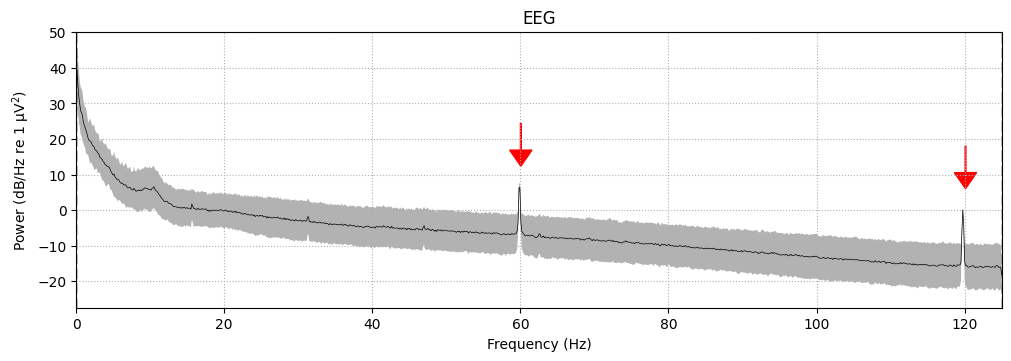

In [139]:
## View Spectrum to Identify Power Line Noise
# Function from MNE Python examples with modifications
def add_arrows(axes):
    """Add arrows at 60 Hz and its harmonics without indexing past data range."""
    harmonics = (60, 120, 180, 240)
    for ax in axes:
        # Choose the plotted line with the most points to derive freqs/psd safely
        lines = [ln for ln in ax.lines if hasattr(ln, "get_xdata")]
        if not lines:
            continue
        line = max(lines, key=lambda ln: len(ln.get_xdata()))
        freqs = np.asarray(line.get_xdata())
        psds = np.asarray(line.get_ydata())
        if freqs.size == 0 or psds.size == 0:
            continue

        fmax_plot = float(freqs[-1])
        for freq in harmonics:
            # Skip harmonics outside the plotted frequency range
            if freq > fmax_plot:
                continue
            # Find insertion index and clamp to valid range
            idx = int(np.searchsorted(freqs, freq, side="left"))
            if idx >= freqs.size:
                idx = freqs.size - 1
            if idx < 0:
                idx = 0

            # Robust neighborhood for peak arrow height
            i0 = max(0, idx - 4)
            i1 = min(psds.size, idx + 5)
            if i0 >= i1:
                y = float(psds[idx])
            else:
                y = float(psds[i0:i1].max())

            # Draw a short downward arrow
            ax.arrow(
                x=float(freqs[idx]),
                y=y + 18,
                dx=0,
                dy=-12,
                color="red",
                width=0.1,
                head_width=3,
                length_includes_head=True,
            )

# Plot PSD and annotate
fig = raw.compute_psd(fmax=125).plot(
    average=True, amplitude=False, picks="data", exclude="bads"
)
add_arrows(fig.axes[:2])

In [151]:
## Notch filter at 60 Hz
freqs = [60.0, 120.0]
raw_filt.notch_filter(freqs=[60.0, 120.0])

Filtering raw data in 1 contiguous segment
Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 1651 samples (6.604 s)

- Upper transition bandwidth: 0.50 Hz
- Filter length: 1651 samples (6.604 s)



<RawArray | 8 x 597088 (2388.4 s), ~36.5 MiB, data loaded>

<RawArray | 8 x 597088 (2388.4 s), ~36.5 MiB, data loaded>
Filtered channels: ['FP2', 'Pz', 'Cz', 'PO8', 'PO7', 'T8', 'T7', 'F2']
Sampling rate: 250.0
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).
Plotting power spectral density (dB=True).


c:\Users\doubl\Desktop\School\Capstone\FYDP-rename_later-\poc\eeg_analysis\.venv_eeg\Lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


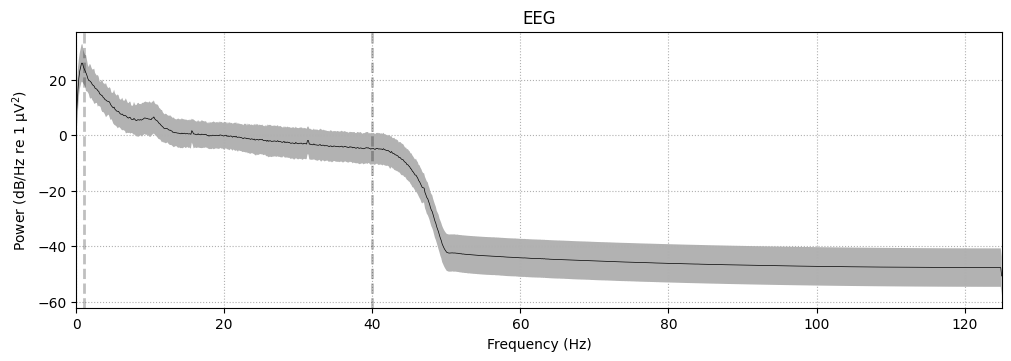

In [141]:
## Display Filtered Data Info and Plot PSD
print(raw_filt)
print("Filtered channels:", raw_filt.ch_names)
print("Sampling rate:", raw_filt.info['sfreq'])
fig = raw_filt.compute_psd(fmax=125).plot(
    average=True, amplitude=False, picks="data", exclude="bads"
)

#### 2. *(Optional)* Re-reference with Fp2 to remove eye artifacts

Re-reference channels 2–8 using common average reference (CAR), excluding FP2. 

In [ ]:
## Common Average Reference (CAR) across channels 2–8
avg_channels = ["PZ", "CZ", "PO8", "PO7", "T8", "T7", "F2"]

ref_mapping = {
    'PZ': avg_channels,
    'CZ': avg_channels,
    'PO8': avg_channels,
    'PO7': avg_channels,
    'T8': avg_channels,
    'T7': avg_channels,
    'F2': avg_channels
}

ch_upper_map = {ch.upper(): ch for ch in raw_filt.ch_names}
picks_in_avg = [ch_upper_map[ch] for ch in avg_channels]

raw_filt, ref_data = mne.set_eeg_reference(raw_filt, ref_channels=picks_in_avg, projection=False)

# Sanity check
avg_std = float(raw_filt.get_data(picks=picks_in_avg).mean(axis=0).std())
print(f"Applied CAR to {len(ref_mapping)} channels (excluding FP2). Post-ref mean(trace) std: {avg_std * 1e6:.2f} μV")

EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Applying a custom ('EEG',) reference.
Applied CAR to 7 channels (excluding FP2). Post-ref mean(trace) std: 0.00 μV


#### 3. Epoch EEG to Gaze-AOI Events

Epoch to events with "Gaze_AOI" event name (AUTO or MANUAL) set as the 0-point. This event will also then be renamed based on the trial condition. 

Epoch duration: -1000 to 1500 (ms)

In [161]:
## Set up Events for MNE Epoching
# Epoch parameters
epoch_dur = [-1.0, 1.5]  # seconds before and after event
baseline = None  # baseline correction from start to event onset

# Convert LSL timestamps to sample indices and times relative to EEG start
sfreq = raw_filt.info['sfreq']
eeg_start_lsl = eeg_df['TIMESTAMP'].iloc[0]  # LSL time of first EEG sample

# Add START and BUTTON events as annotations (visible markers, not epochs)
ref_events = events_df[events_df['Type'].isin(['START', 'BUTTON'])].copy()
if len(ref_events) > 0:
    onsets = (ref_events['LSL_Time'] - eeg_start_lsl).values  # seconds relative to raw start
    durations = np.zeros(len(onsets))
    descriptions = ref_events['Type'].values
    
    annotations = mne.Annotations(onset=onsets, duration=durations, description=descriptions)
    raw_filt.set_annotations(annotations)
    print(f"Added {len(annotations)} annotations (START/BUTTON) to continuous EEG data.")

# Build event_id mapping: ONLY condition labels for Gaze AOI events
events_aoi = events_df[events_df['Event'] == 'Gaze_AOI'].dropna(subset=['LSL_Time', 'CONDITION']).copy()
unique_conditions = sorted(events_aoi['CONDITION'].dropna().unique())
event_id = {cond: i + 1 for i, cond in enumerate(unique_conditions)}

print("\nEvent ID mapping:")
print(event_id)

# Compute sample indices for Gaze AOI events
events_aoi['sample_idx'] = ((events_aoi['LSL_Time'] - eeg_start_lsl) * sfreq).astype(int)

# Assign event IDs based on CONDITION
events_aoi['event_id'] = events_aoi['CONDITION'].map(event_id)

# Create MNE events array: (n_events, 3) with columns [sample, 0, event_id]
events_mne = events_aoi[['sample_idx', 'event_id']].values
events_mne = np.column_stack([events_mne[:, 0], np.zeros(len(events_mne), dtype=int), events_mne[:, 1]])

print(f"\nCreated {len(events_mne)} MNE events.")
print("MNE events array (first 5):")
print(events_mne[:5])

Added 116 annotations (START/BUTTON) to continuous EEG data.

Event ID mapping:
{'hailey/eyes': 1, 'hailey/open': 2, 'hailey/turn': 3, 'unfamiliar/eyes': 4, 'unfamiliar/open': 5, 'unfamiliar/turn': 6, 'yoonhee/turn': 7}

Created 58 MNE events.
MNE events array (first 5):
[[ 8784     0     7]
 [23551     0     7]
 [31125     0     7]
 [36845     0     7]
 [43076     0     7]]


In [ ]:
## Create Epochs at Gaze-AOI events only
epochs = mne.Epochs(
    raw_filt,
    events=events_mne,
    event_id=event_id,
    tmin=epoch_dur[0],
    tmax=epoch_dur[1],
    baseline=None,  # no baseline correction yet
    preload=True,
)

print(epochs)

Not setting metadata
58 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 58 events and 626 original time points ...
58 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 58 events and 626 original time points ...
0 bad epochs dropped
<Epochs | 58 events (all good), -1 – 1.5 s (baseline off), ~2.2 MiB, data loaded,
 'hailey/eyes': 10
 'hailey/open': 10
 'hailey/turn': 9
 'unfamiliar/eyes': 10
 'unfamiliar/open': 9
 'unfamiliar/turn': 5
 'yoonhee/turn': 5>
0 bad epochs dropped
<Epochs | 58 events (all good), -1 – 1.5 s (baseline off), ~2.2 MiB, data loaded,
 'hailey/eyes': 10
 'hailey/open': 10
 'hailey/turn': 9
 'unfamiliar/eyes': 10
 'unfamiliar/open': 9
 'unfamiliar/turn': 5
 'yoonhee/turn': 5>


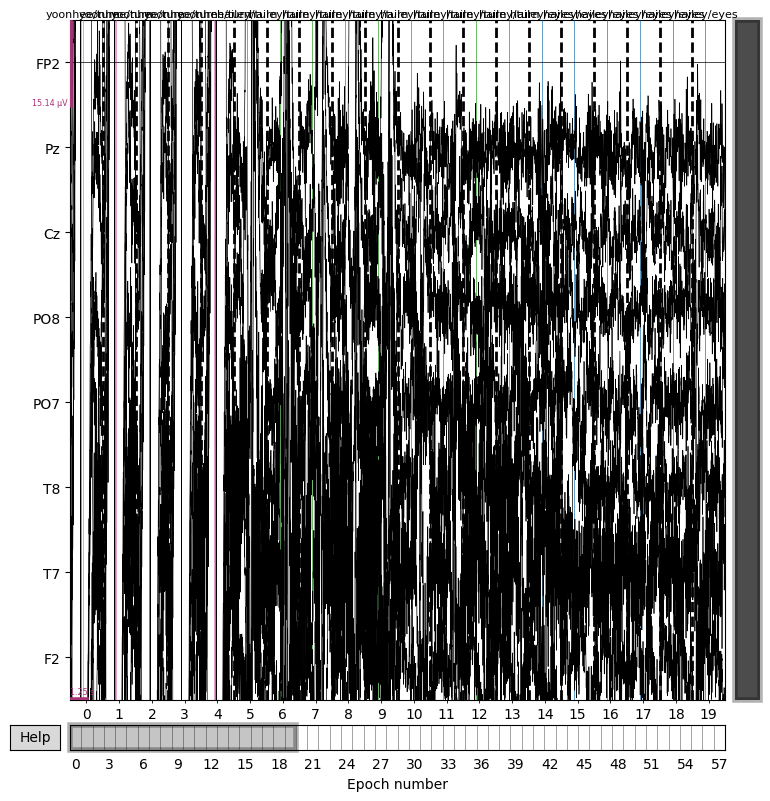

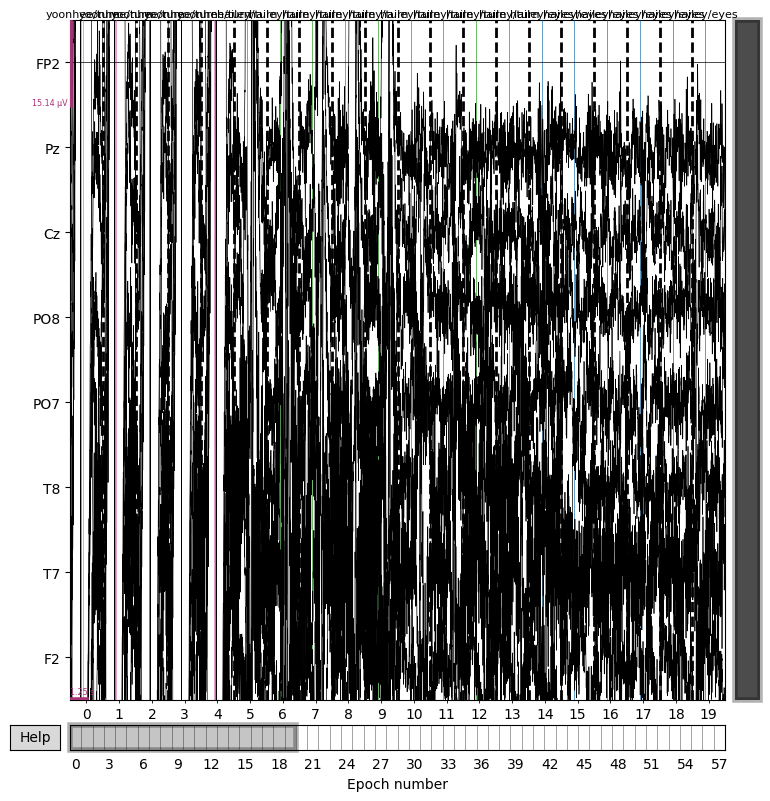

In [88]:
## Plot Epochs
epochs.plot(scalings='auto', event_id=True, events=True)

In [97]:
## Save epoched EEG data to file
filename = "poc_eeg_epochs_1_reref-epo.fif"
epochs.save(filename, overwrite=True)

Overwriting existing file.
Overwriting existing file.
Overwriting existing file.
Overwriting existing file.
Overwriting existing file.


[WindowsPath('c:/Users/doubl/Desktop/School/Capstone/FYDP-rename_later-/poc/eeg_analysis/poc_eeg_epochs_1-epo.fif')]

#### 4. Subtract baseline mean from each Epoch  

Set baseline for correction BEFORE movement occurs (e.g. head movement, eye movement, eye-opening)

In [163]:
## Load epoched EEG data from file
filename = "poc_eeg_epochs_1-epo.fif"
epochs = mne.read_epochs(filename, preload=True)

Reading c:\Users\doubl\Desktop\School\Capstone\FYDP-rename_later-\poc\eeg_analysis\poc_eeg_epochs_1-epo.fif ...
    Found the data of interest:
        t =   -1000.00 ...    1500.00 ms
        0 CTF compensation matrices available
Not setting metadata
58 matching events found
No baseline correction applied
0 projection items activated


##### Investigate Baselines for Each Movement Type

Not setting metadata


19 matching events found
No baseline correction applied
0 projection items activated
combining channels using "median"
No baseline correction applied
0 projection items activated
combining channels using "median"


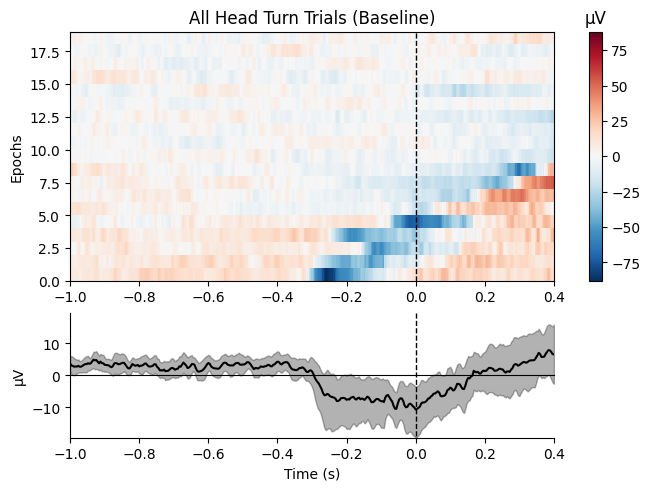

[<Figure size 640x480 with 3 Axes>]

In [77]:
## Check all head turn trials to find movement noise duration
# Crop epochs to desired time range first
epochs_cropped = epochs.copy().crop(tmin=-1.0, tmax=0.4)
epochs_cropped['turn'].plot_image(combine="median", sigma=0, title='All Head Turn Trials (Baseline)')

Not setting metadata
20 matching events found
No baseline correction applied
20 matching events found
No baseline correction applied


0 projection items activated
combining channels using "median"
combining channels using "median"


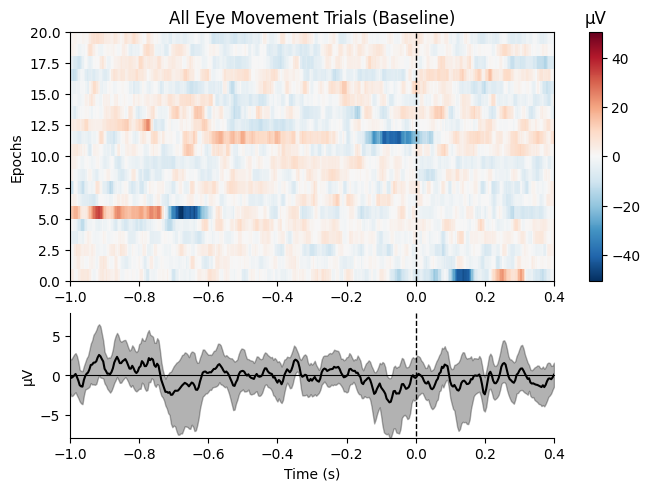

[<Figure size 640x480 with 3 Axes>]

In [78]:
## Check all eye movement trials to find movement noise duration
epochs_cropped['eyes'].plot_image(combine="median", sigma=0, title='All Eye Movement Trials (Baseline)')

Not setting metadata
19 matching events found
No baseline correction applied
19 matching events found
No baseline correction applied


0 projection items activated
combining channels using "median"
combining channels using "median"


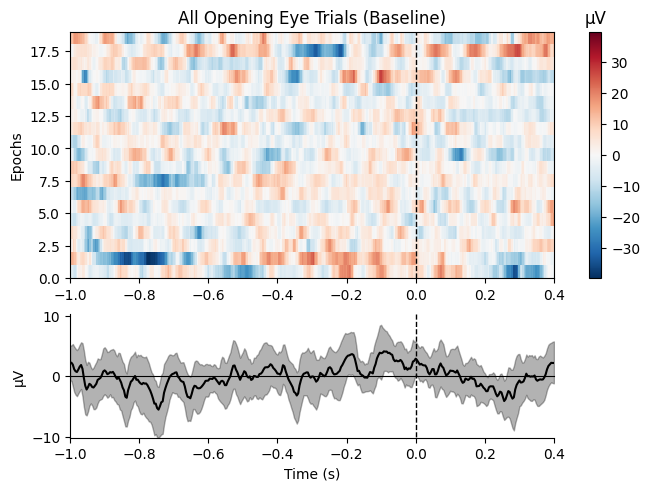

[<Figure size 640x480 with 3 Axes>]

In [79]:
## Check all opening eye trials to find movement noise duration
epochs_cropped['open'].plot_image(combine="median", sigma=0, title='All Opening Eye Trials (Baseline)')

**Results**
- *Head Turn:* Use baseline before `-0.3`s
- *Eye movement:* Use baseline before `-0.18`s. One epoch is abnormal, make sure to reject bad epochs.
- *Opening eyes:* May disregard these for analysis since the baseline is abnormal. If still desired, use baseline from before `-0.1`s

##### Reject Bad Trials from Baseline

In [164]:
## Load epoched EEG data from file
filename = "poc_eeg_epochs_1_reref-epo.fif"
epochs = mne.read_epochs(filename, preload=True)

Reading c:\Users\doubl\Desktop\School\Capstone\FYDP-rename_later-\poc\eeg_analysis\poc_eeg_epochs_1_reref-epo.fif ...
    Found the data of interest:
        t =   -1000.00 ...    1500.00 ms
        0 CTF compensation matrices available
Not setting metadata
58 matching events found
No baseline correction applied
0 projection items activated


Condition-specific baseline rejection summary:
- turn: dropped 5/19 (kept 14)
- eyes: dropped 0/20 (kept 20)
- open: dropped 0/19 (kept 19)
Total to drop: 5 of 58
Dropped 5 epochs: 0, 1, 2, 3, 4


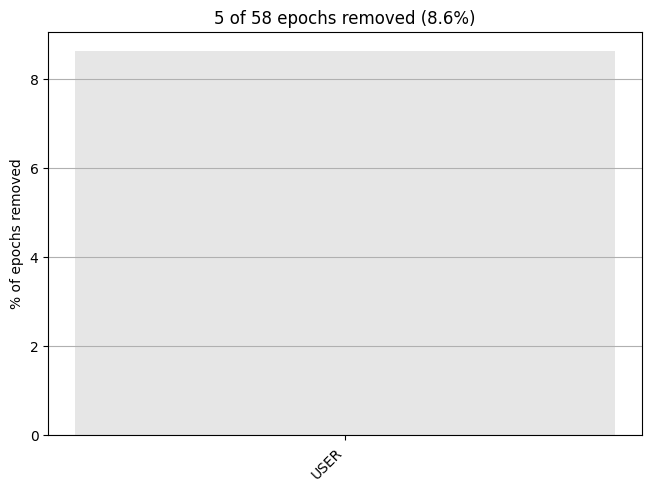

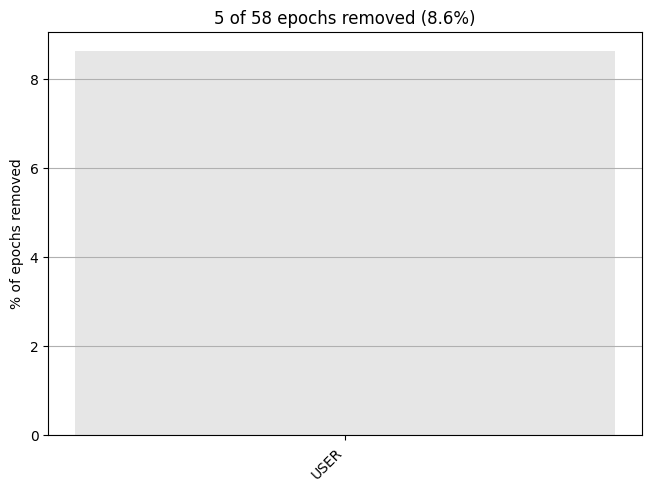

In [165]:
## Reject bad trials using condition-specific baseline windows
# We compute peak-to-peak (PTP) amplitude within the baseline window for each condition
# and drop epochs exceeding a threshold.

amp_thresh = 150e-6  # 150 µV
# Baseline windows per movement type (seconds, relative to event onset)
baseline_windows = {
    'turn': (-1.0, -0.3),
    'eyes': (-1.0, -0.18),
    'open': (-1.0, -0.1),
}

def _movement_from_label(label: str) -> str:
    if not isinstance(label, str):
        return 'other'
    parts = label.lower().split('/')
    return parts[-1] if parts else 'other'

# Map each epoch to its condition label and movement type
inv_event_id = {v: k for k, v in epochs.event_id.items()}
labels = [inv_event_id.get(code, str(code)) for code in epochs.events[:, 2]]
movements = [_movement_from_label(lb) for lb in labels]

import numpy as np
X = epochs.get_data()  # shape (n_epochs, n_channels, n_times)

bad_indices = set()
summary = {}

# Evaluate defined movements
for mv, (tmin, tmax) in baseline_windows.items():
    ep_idx = [i for i, m in enumerate(movements) if m == mv]
    if not ep_idx:
        continue
    i0, i1 = epochs.time_as_index([tmin, tmax])
    i0, i1 = (i0, i1) if i0 <= i1 else (i1, i0)
    X_mv = X[ep_idx, :, i0:i1 + 1]
    ptp = np.ptp(X_mv, axis=2)  # peak-to-peak per channel
    bad_mask = (ptp > amp_thresh).any(axis=1)
    dropped = [ep_idx[i] for i, is_bad in enumerate(bad_mask) if is_bad]
    bad_indices.update(dropped)
    summary[mv] = dict(total=len(ep_idx), dropped=len(dropped), kept=len(ep_idx) - len(dropped))

# Handle any other movements with a default baseline window
other_idx = [i for i, m in enumerate(movements) if m not in baseline_windows]
if other_idx:
    tmin_def, tmax_def = -1.0, -0.3
    i0, i1 = epochs.time_as_index([tmin_def, tmax_def])
    i0, i1 = (i0, i1) if i0 <= i1 else (i1, i0)
    X_oth = X[other_idx, :, i0:i1 + 1]
    ptp = X_oth.ptp(axis=2)
    bad_mask = (ptp > amp_thresh).any(axis=1)
    dropped = [other_idx[i] for i, is_bad in enumerate(bad_mask) if is_bad]
    bad_indices.update(dropped)
    summary['other'] = dict(total=len(other_idx), dropped=len(dropped), kept=len(other_idx) - len(dropped))

bad_indices = sorted(bad_indices)
print("Condition-specific baseline rejection summary:")
for mv, stats in summary.items():
    print(f"- {mv}: dropped {stats['dropped']}/{stats['total']} (kept {stats['kept']})")
print(f"Total to drop: {len(bad_indices)} of {len(epochs)}")

epochs.drop(bad_indices)
epochs.plot_drop_log()

##### Subtract Baseline Mean from Each Epoch

Subtract the baseline mean from each epoch, subject to the baseline times for each movement type.
- Head turn: -1s to -0.3s 
- Eye movement: -1s to -0.18s
- Opening eyes: -1s to -0.1s

Applying baseline correction (mode: mean)
No projector specified for this dataset. Please consider the method self.add_proj.
No projector specified for this dataset. Please consider the method self.add_proj.


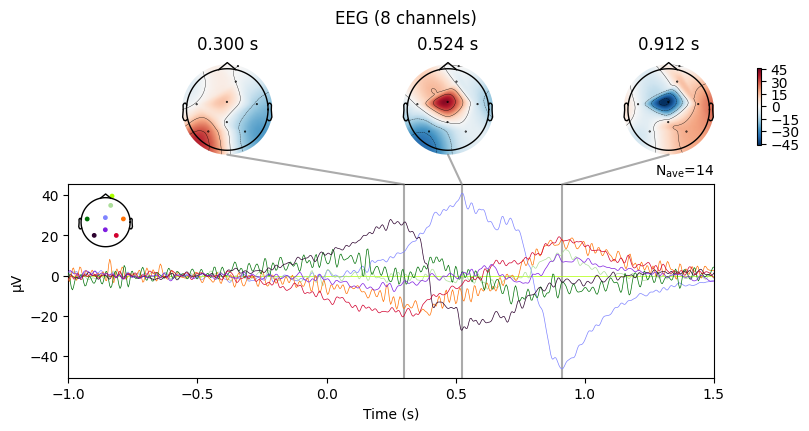

Applying baseline correction (mode: mean)
No projector specified for this dataset. Please consider the method self.add_proj.
No projector specified for this dataset. Please consider the method self.add_proj.


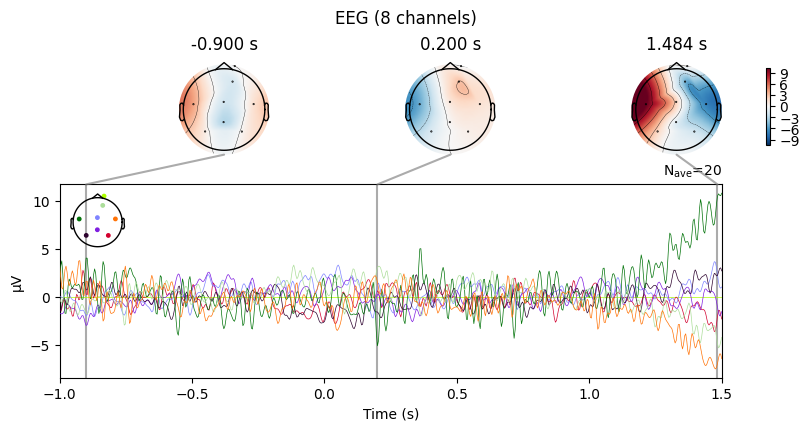

Applying baseline correction (mode: mean)
No projector specified for this dataset. Please consider the method self.add_proj.
No projector specified for this dataset. Please consider the method self.add_proj.


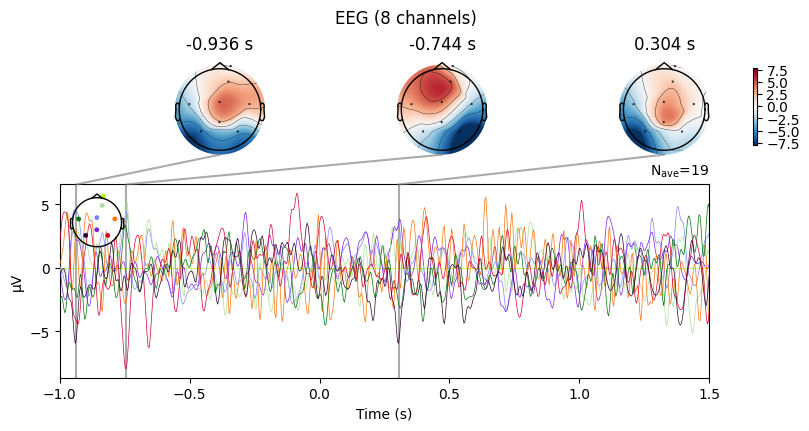

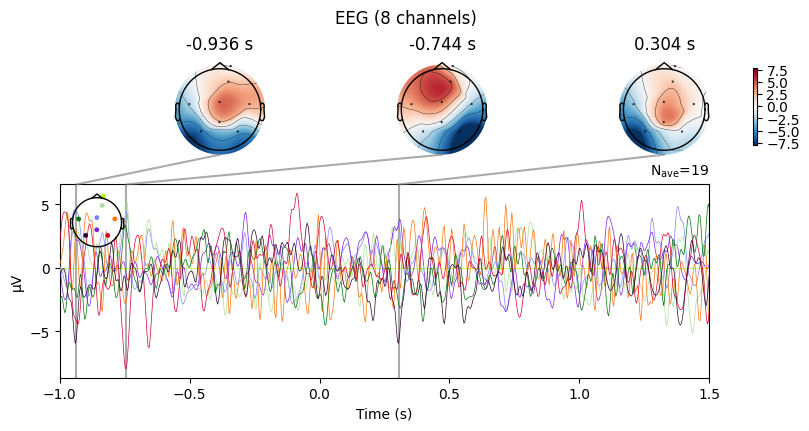

In [166]:
baseline_turn = (-1.0, -0.3)
baseline_eyes = (-1.0, -0.18)
baseline_open = (-1.0, -0.1)

epochs['turn'].average().apply_baseline(baseline=baseline_turn).plot_joint()
epochs['eyes'].average().apply_baseline(baseline=baseline_eyes).plot_joint()
epochs['open'].average().apply_baseline(baseline=baseline_open).plot_joint()

Not setting metadata
14 matching events found
No baseline correction applied
0 projection items activated
combining channels using "mean"
14 matching events found
No baseline correction applied
0 projection items activated
combining channels using "mean"


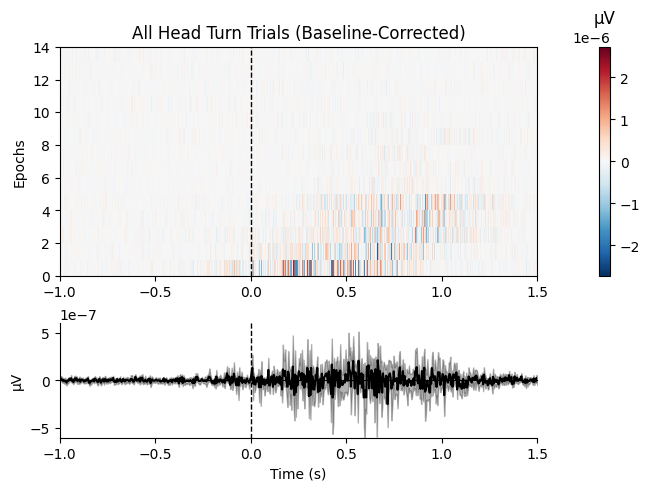

Not setting metadata
20 matching events found
No baseline correction applied
0 projection items activated
combining channels using "mean"
20 matching events found
No baseline correction applied
0 projection items activated
combining channels using "mean"


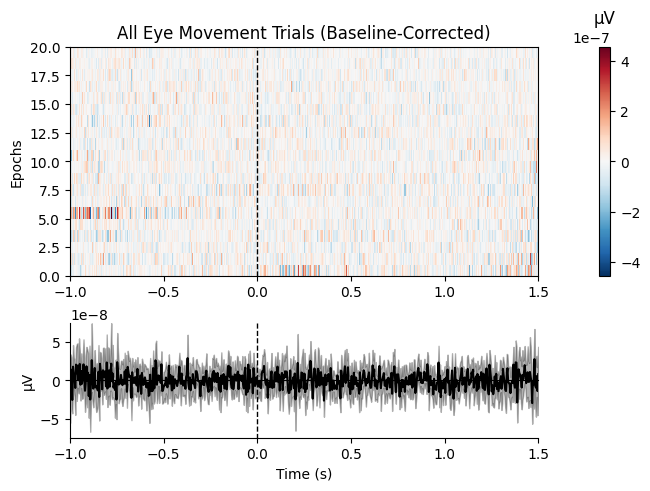

Not setting metadata
19 matching events found
19 matching events found
No baseline correction applied
0 projection items activated
combining channels using "mean"
No baseline correction applied
0 projection items activated
combining channels using "mean"


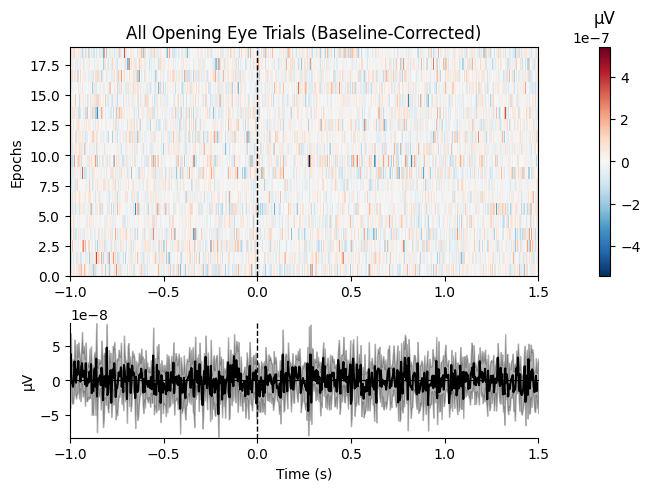

[<Figure size 640x480 with 3 Axes>]

In [167]:
## Plot Evoked Responses per Condition
epochs['turn'].plot_image(combine="mean", sigma=0, title='All Head Turn Trials (Baseline-Corrected)')
epochs['eyes'].plot_image(combine="mean", sigma=0, title='All Eye Movement Trials (Baseline-Corrected)')
epochs['open'].plot_image(combine="mean", sigma=0, title='All Opening Eye Trials (Baseline-Corrected)')

In [168]:
## Save baseline-corrected epoched EEG data to file
filename = "poc_eeg_epochs_1_reref_baseline-epo.fif"
epochs.save(filename, overwrite=True)

Overwriting existing file.
Overwriting existing file.
Overwriting existing file.
Overwriting existing file.
Overwriting existing file.


[WindowsPath('c:/Users/doubl/Desktop/School/Capstone/FYDP-rename_later-/poc/eeg_analysis/poc_eeg_epochs_1_reref_baseline-epo.fif')]

#### 5. *(Optional)* Independent Component Analysis (ICA) to remove artifacts

In [169]:
## Load epoched EEG data from file
filename = "poc_eeg_epochs_1_reref_baseline-epo.fif"
epochs = mne.read_epochs(filename, preload=True)

Reading c:\Users\doubl\Desktop\School\Capstone\FYDP-rename_later-\poc\eeg_analysis\poc_eeg_epochs_1_reref_baseline-epo.fif ...
    Found the data of interest:
        t =   -1000.00 ...    1500.00 ms
        0 CTF compensation matrices available
Not setting metadata
53 matching events found
No baseline correction applied
0 projection items activated


Fitting ICA to data using 8 channels (please be patient, this may take a while)
Selecting by explained variance: 6 components
Selecting by explained variance: 6 components
Fitting ICA took 1.0s.
Using EOG channel: FP2
Fitting ICA took 1.0s.
Using EOG channel: FP2
ICA: suggested EOG components: []
Applying ICA to Epochs instance
    Transforming to ICA space (6 components)
    Zeroing out 0 ICA components
    Projecting back using 8 PCA components
ICA: suggested EOG components: []
Applying ICA to Epochs instance
    Transforming to ICA space (6 components)
    Zeroing out 0 ICA components
    Projecting back using 8 PCA components


c:\Users\doubl\Desktop\School\Capstone\FYDP-rename_later-\poc\eeg_analysis\.venv_eeg\Lib\site-packages\mne\preprocessing\ica.py:118: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  out = [func(a, y.ravel()) for a in x]


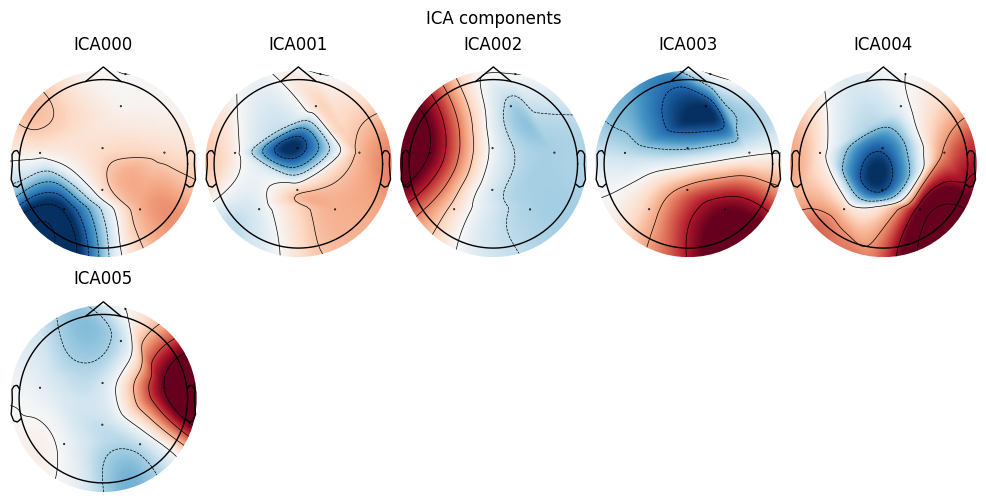

Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
5 matching events found
No baseline correction applied
0 projection items activated


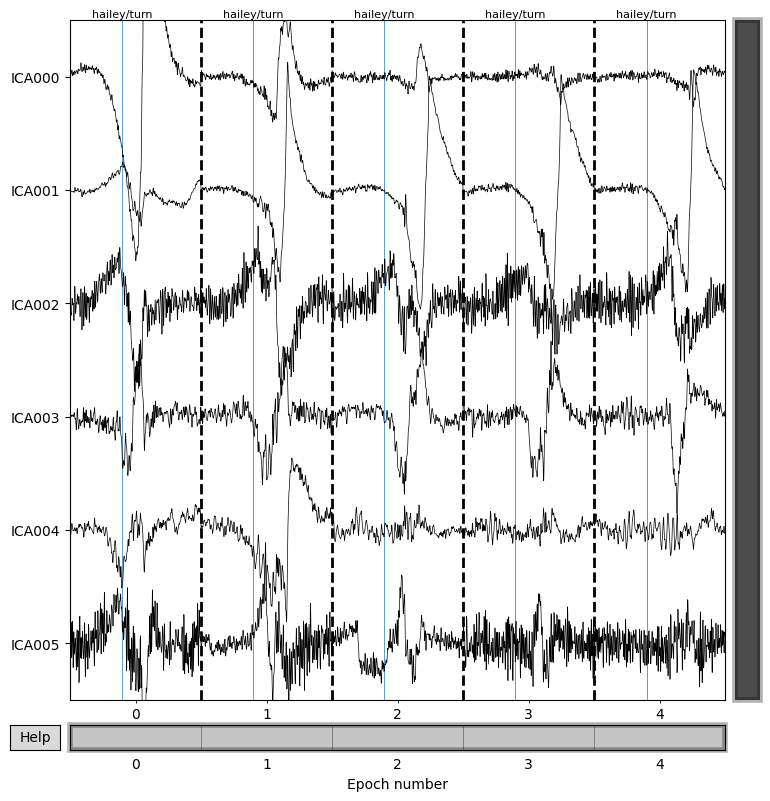

Overwriting existing file.
Writing ICA solution to c:\Users\doubl\Desktop\School\Capstone\FYDP-rename_later-\poc\eeg_analysis\poc_eeg_ica.fif...
Overwriting existing file.
Overwriting existing file.
Overwriting existing file.
Overwriting existing file.
Saved ICA solution to poc_eeg_ica.fif and cleaned epochs to poc_eeg_epochs_1_reref_baseline_ica-epo.fif.
Writing ICA solution to c:\Users\doubl\Desktop\School\Capstone\FYDP-rename_later-\poc\eeg_analysis\poc_eeg_ica.fif...
Overwriting existing file.
Overwriting existing file.
Overwriting existing file.
Overwriting existing file.
Saved ICA solution to poc_eeg_ica.fif and cleaned epochs to poc_eeg_epochs_1_reref_baseline_ica-epo.fif.


In [171]:
# Run ICA to remove ocular components using FP2 as EOG proxy
from mne.preprocessing import ICA, create_eog_epochs

# Ensure epochs are the latest baseline-corrected or artifact-rejected set
n_components = 0.99  # keep 99% variance
ica = ICA(n_components=n_components, method='fastica', random_state=97, max_iter='auto')
ica.fit(epochs)

# Try to detect EOG-related ICs using FP2 as a proxy
ch_upper_map = {ch.upper(): ch for ch in epochs.ch_names}
fp2_name = ch_upper_map.get('FP2', None)

if fp2_name is not None:
    eog_idx, eog_scores = ica.find_bads_eog(epochs, ch_name=fp2_name)
else:
    # Fallback: let MNE try to infer without a channel name
    eog_idx, eog_scores = ica.find_bads_eog(epochs)

print(f"ICA: suggested EOG components: {eog_idx}")
ica.exclude = eog_idx

# Apply ICA to create a cleaned copy
epochs_ica = ica.apply(epochs.copy())

# Optional quick-look plots (can be commented out if too heavy)
try:
    ica.plot_components(inst=epochs)  # spatial maps
except Exception as e:
    print(f"ICA component plot skipped: {e}")

try:
    ica.plot_sources(epochs[:5])  # timecourses for first few epochs
except Exception as e:
    print(f"ICA source plot skipped: {e}")

# Save ICA and cleaned epochs
ica_fname = 'poc_eeg_ica.fif'
clean_fname = 'poc_eeg_epochs_1_reref_baseline_ica-epo.fif'
ica.save(ica_fname, overwrite=True)
epochs_ica.save(clean_fname, overwrite=True)

print(f"Saved ICA solution to {ica_fname} and cleaned epochs to {clean_fname}.")

combining channels using GFP (eeg channels)
combining channels using GFP (eeg channels)
combining channels using GFP (eeg channels)


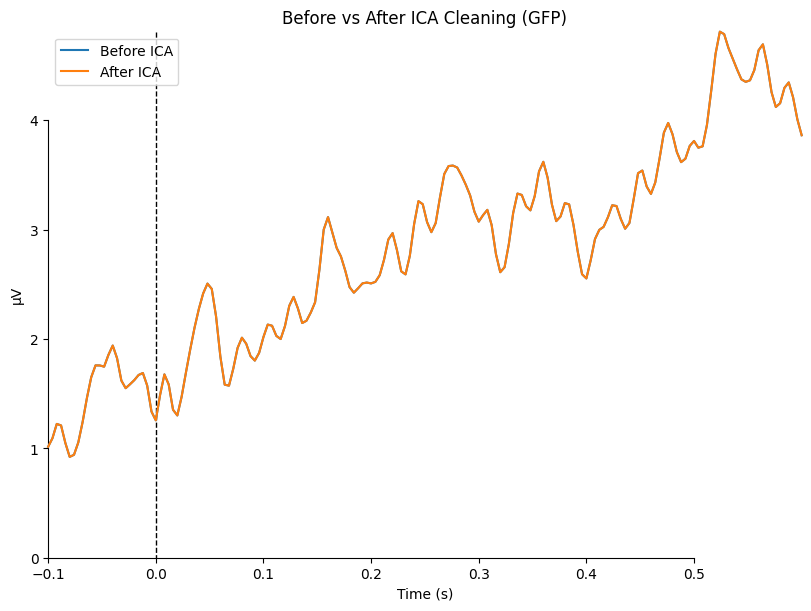

[<Figure size 800x600 with 1 Axes>]

In [176]:
## Visualize Epochs Before/After ICA Cleaning
epochs_cropped = epochs.copy().crop(tmin=-0.1, tmax=0.6)
epochs_ica_cropped = epochs_ica.copy().crop(tmin=-0.1, tmax=0.6)

mne.viz.plot_compare_evokeds(
    {
        'Before ICA': epochs_cropped.average(),
        'After ICA': epochs_ica_cropped.average()
    },
    picks='data',
    title='Before vs After ICA Cleaning'
)

Exactly the same, therefore no cleaning was done with ICA.

## ERP Results/Analysis

Visualize and calculate the ERP results across trials.

This should allow for visualization of specific eye movement types and targets, averaging or selecting specific trials as necessary.

We also want to analyze N250 (PO8,PO7,T8,T7,F2) and P300 (Pz,Cz) in particular. The plots will show a shaded region that is considered when averaging to find these components, and the scripts should print out the associated voltage level (Mean +/- SD)

In [3]:
import mne
## Load epoch data
filename = "poc_eeg_epochs_1_reref_baseline_ica-epo.fif"
epochs = mne.read_epochs(filename, preload=True)

Reading c:\Users\doubl\Desktop\School\Capstone\FYDP-rename_later-\poc\eeg_analysis\poc_eeg_epochs_1_reref_baseline_ica-epo.fif ...
    Found the data of interest:
        t =   -1000.00 ...    1500.00 ms
        0 CTF compensation matrices available
Not setting metadata
53 matching events found
No baseline correction applied
0 projection items activated


### Plotting Function

In [177]:
# Plot params
error_region_alpha = 0.2 # transparency for shaded error region
individual_trial_alpha = 0.4 # transparency for individual trials in grand plot

In [178]:
## Familiar vs Unfamiliar ERP plotter
from typing import Union, Sequence, Dict, Any
import numpy as np
import matplotlib.pyplot as plt
import mne


def plot_familiar_vs_unfamiliar(
    epochs: mne.Epochs,
    component: str = "N250",
    familiar_selector: Union[None, str, Sequence[Union[str, int, bool]]] = None,
    unfamiliar_selector: Union[None, str, Sequence[Union[str, int, bool]]] = None,
    picks: Union[None, Sequence[str]] = None,
    time_window: tuple = (0, 0.6),
    average: bool = True,
    avg_method: str = "mean",  # 'mean' or 'median'
    smooth_ms: Union[None, float, int] = None,  # moving-average window (ms)
    title: Union[None, str] = None,
) -> tuple:
    """Plot familiar vs unfamiliar ERP components with optional averaging and smoothing."""
    
    # Validate inputs
    component = component.upper()
    if component not in {"N250", "P300"}:
        raise ValueError("component must be 'N250' or 'P300'")
    if avg_method.lower() not in {"mean", "median"}:
        raise ValueError("avg_method must be 'mean' or 'median'")

    # Component-specific parameters
    component_params = {
        "N250": {"peak_time": 0.250, "default_picks": ["PO8", "PO7", "T8", "T7", "F2"]},
        "P300": {"peak_time": 0.300, "default_picks": ["Pz", "Cz"]}
    }
    
    peak_time = component_params[component]["peak_time"]
    analysis_window = (peak_time - 0.050, peak_time + 0.050)
    default_picks = component_params[component]["default_picks"]
    
    # Resolve channel picks
    def _resolve_picks(channel_candidates):
        """Convert channel names to available channels in epochs."""
        channel_map = {ch.upper(): ch for ch in epochs.ch_names}
        resolved = [channel_map[c.upper()] for c in channel_candidates if c.upper() in channel_map]
        if not resolved:
            raise RuntimeError(f"No requested channels found. Tried {channel_candidates}. Available: {epochs.ch_names}")
        return resolved

    picks = _resolve_picks(default_picks if picks is None else picks)

    # Get epoch labels
    event_id_to_label = {v: k for k, v in epochs.event_id.items()}
    epoch_labels = [event_id_to_label.get(code, str(code)) for code in epochs.events[:, 2]]

    def _get_epoch_indices(selector, auto_mask=None):
        """Get epoch indices based on selector and auto_mask."""
        n_epochs = len(epochs)
        
        # Use auto_mask if no selector provided
        if selector is None:
            return np.flatnonzero(auto_mask) if auto_mask is not None else np.arange(n_epochs)
        
        # Boolean mask
        if (isinstance(selector, (list, np.ndarray)) and len(selector) == n_epochs 
            and all(isinstance(x, (bool, np.bool_)) for x in selector)):
            return np.flatnonzero(selector)
        
        # Integer indices
        if (isinstance(selector, (list, np.ndarray)) and len(selector) > 0 
            and all(isinstance(x, (int, np.integer)) for x in selector)):
            indices = np.asarray(selector, dtype=int)
            if indices.min() < 0 or indices.max() >= n_epochs:
                raise IndexError("Selector indices out of range")
            return np.unique(indices)
        
        # String matching
        def _matches_label(search_string):
            search_string = search_string.lower()
            return np.array([search_string in str(label).lower() for label in epoch_labels], dtype=bool)
        
        if isinstance(selector, str):
            return np.flatnonzero(_matches_label(selector))
        
        if isinstance(selector, (list, tuple)) and all(isinstance(x, str) for x in selector):
            mask = np.zeros(n_epochs, dtype=bool)
            for s in selector:
                mask |= _matches_label(s)
            return np.flatnonzero(mask)
        
        raise TypeError("Unsupported selector type")

    # Auto-detect familiar/unfamiliar epochs
    prefixes = [str(label).split('/')[0].lower() for label in epoch_labels]
    auto_familiar = np.array([prefix in {"hailey", "yoonhee"} for prefix in prefixes])
    auto_unfamiliar = np.array([prefix == "unfamiliar" for prefix in prefixes])

    familiar_indices = _get_epoch_indices(familiar_selector, auto_familiar)
    unfamiliar_indices = _get_epoch_indices(unfamiliar_selector, auto_unfamiliar)
    
    if familiar_indices.size == 0:
        raise ValueError("No familiar epochs selected")
    if unfamiliar_indices.size == 0:
        raise ValueError("No unfamiliar epochs selected")

    # Extract and prepare data
    tmin, tmax = time_window
    familiar_epochs = epochs[familiar_indices].copy().pick(picks=picks).crop(tmin=tmin, tmax=tmax)
    unfamiliar_epochs = epochs[unfamiliar_indices].copy().pick(picks=picks).crop(tmin=tmin, tmax=tmax)

    sfreq = float(familiar_epochs.info.get('sfreq', epochs.info.get('sfreq', 1.0)))

    def _smooth_data(data: np.ndarray, window_size: int) -> np.ndarray:
        """Apply moving average smoothing to data."""
        if window_size <= 1:
            return data
        
        kernel = np.ones(window_size, dtype=float) / window_size
        
        if data.ndim == 1:
            return np.convolve(data, kernel, mode='same')
        
        return np.apply_along_axis(lambda x: np.convolve(x, kernel, mode='same'), 
                                 axis=1, arr=data)

    # Calculate smoothing window
    smooth_window = 0
    if smooth_ms is not None:
        smooth_window = int(round(float(smooth_ms) * sfreq / 1000.0))
        if smooth_window < 1:
            smooth_window = 0
        # Prefer odd window size for symmetric smoothing
        if smooth_window % 2 == 0 and smooth_window > 1:
            smooth_window += 1

    # Get data (mean across channels)
    familiar_data = familiar_epochs.get_data().mean(axis=1)  # (n_familiar, n_times)
    unfamiliar_data = unfamiliar_epochs.get_data().mean(axis=1)  # (n_unfamiliar, n_times)
    
    times = familiar_epochs.times

    # Create plot
    fig, ax = plt.subplots(figsize=(8, 4))
    
    # Plot individual trials or averages
    if not average:
        # Apply smoothing to individual trials if requested
        if smooth_window > 1:
            familiar_data_smoothed = _smooth_data(familiar_data, smooth_window)
            unfamiliar_data_smoothed = _smooth_data(unfamiliar_data, smooth_window)
        else:
            familiar_data_smoothed = familiar_data
            unfamiliar_data_smoothed = unfamiliar_data
            
        # Plot individual trials
        for trial in familiar_data_smoothed:
            ax.plot(times, trial * 1e6, color="#1f77b4", alpha=individual_trial_alpha, linewidth=0.8)
        for trial in unfamiliar_data_smoothed:
            ax.plot(times, trial * 1e6, color="#d62728", alpha=individual_trial_alpha, linewidth=0.8)
        
        # Calculate averages for the lines
        familiar_avg = familiar_data_smoothed.mean(axis=0)
        unfamiliar_avg = unfamiliar_data_smoothed.mean(axis=0)
        
        familiar_label = "Familiar"
        unfamiliar_label = "Unfamiliar"
    else:  
        # Apply smoothing to all trials first
        if smooth_window > 1:
            familiar_data_smoothed = _smooth_data(familiar_data, smooth_window)
            unfamiliar_data_smoothed = _smooth_data(unfamiliar_data, smooth_window)
        else:
            familiar_data_smoothed = familiar_data
            unfamiliar_data_smoothed = unfamiliar_data
        
        # For median averaging, smooth the median waveform instead of individual trials
        if avg_method.lower() == 'median':
            familiar_median = np.median(familiar_data, axis=0)
            unfamiliar_median = np.median(unfamiliar_data, axis=0)
            
            if smooth_window > 1:
                familiar_avg = _smooth_data(familiar_median, smooth_window)
                unfamiliar_avg = _smooth_data(unfamiliar_median, smooth_window)
            else:
                familiar_avg = familiar_median
                unfamiliar_avg = unfamiliar_median
            
            # Calculate standard error from smoothed median data
            familiar_sem = familiar_data_smoothed.std(axis=0) / np.sqrt(len(familiar_data_smoothed))
            unfamiliar_sem = unfamiliar_data_smoothed.std(axis=0) / np.sqrt(len(unfamiliar_data_smoothed))
        else:
            familiar_avg = familiar_data_smoothed.mean(axis=0)
            unfamiliar_avg = unfamiliar_data_smoothed.mean(axis=0)
            
            # Calculate standard error from smoothed data for error bars
            familiar_sem = familiar_data_smoothed.std(axis=0) / np.sqrt(len(familiar_data_smoothed))
            unfamiliar_sem = unfamiliar_data_smoothed.std(axis=0) / np.sqrt(len(unfamiliar_data_smoothed))
        
        # Add shaded error bars based on smoothed data
        ax.fill_between(times, 
                       (familiar_avg - familiar_sem) * 1e6, 
                       (familiar_avg + familiar_sem) * 1e6, 
                       color="#1f77b4", alpha=error_region_alpha)
        ax.fill_between(times, 
                       (unfamiliar_avg - unfamiliar_sem) * 1e6, 
                       (unfamiliar_avg + unfamiliar_sem) * 1e6, 
                       color="#d62728", alpha=error_region_alpha)

        familiar_label = f"Familiar ({avg_method})"
        unfamiliar_label = f"Unfamiliar ({avg_method})"

    # Plot average lines
    ax.plot(times, familiar_avg * 1e6, color="#1f77b4", linewidth=2.0, label=familiar_label)
    ax.plot(times, unfamiliar_avg * 1e6, color="#d62728", linewidth=2.0, label=unfamiliar_label)

    # Add component markers
    ax.axvline(peak_time, color="k", linestyle="--", linewidth=1.2, 
               label=f"{component} ({int(peak_time*1000)} ms)")
    ax.axvspan(analysis_window[0], analysis_window[1], color="k", alpha=0.10)

    # Format plot
    ax.set_xlim(tmin, tmax)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude (µV)")
    
    if title:
        ax.set_title(title)
    else:
        ax.set_title(f"{component} Familiarity ERP ({', '.join(picks)})")
        
    ax.legend(frameon=False)
    ax.grid(True, alpha=0.2)

    # Calculate statistics in analysis window (unsmoothed data)
    in_window_mask = (times >= analysis_window[0]) & (times <= analysis_window[1])
        
    familiar_values = familiar_data[:, in_window_mask].mean(axis=1) * 1e6
    unfamiliar_values = unfamiliar_data[:, in_window_mask].mean(axis=1) * 1e6

    stats = {
        "component": component,
        "avg_method": avg_method.lower(),
        "smooth_ms": float(smooth_ms) if smooth_ms is not None else None,
        "window_s": list(analysis_window),
        "channels": list(picks),
        "Familiar": {
            "n": int(familiar_data.shape[0]), 
            "mean_uV": float(np.mean(familiar_values)), 
            "sd_uV": float(np.std(familiar_values, ddof=1)) if familiar_values.size > 1 else float("nan")
        },
        "Unfamiliar": {
            "n": int(unfamiliar_data.shape[0]), 
            "mean_uV": float(np.mean(unfamiliar_values)), 
            "sd_uV": float(np.std(unfamiliar_values, ddof=1)) if unfamiliar_values.size > 1 else float("nan")
        },
    }

    # Print summary
    print(f"{component} analysis:")
    print(f"  Window: {analysis_window[0]:.3f}-{analysis_window[1]:.3f}s")
    print(f"  Channels: {picks}")
    print(f"  Method: {stats['avg_method']}, Smoothing: {stats['smooth_ms']}ms")
    print(f"  Familiar: n={stats['Familiar']['n']}, mean={stats['Familiar']['mean_uV']:.2f} µV, "
          f"sd={stats['Familiar']['sd_uV']:.2f} µV" if familiar_values.size > 1 else "NA")
    print(f"  Unfamiliar: n={stats['Unfamiliar']['n']}, mean={stats['Unfamiliar']['mean_uV']:.2f} µV, "
          f"sd={stats['Unfamiliar']['sd_uV']:.2f} µV" if unfamiliar_values.size > 1 else "NA")

    plt.show()
    return fig, stats

### Plot N250 

#### Parieto-occipital channels averaged (T7, T8, PO7, PO8)

N250 analysis:
  Window: 0.200-0.300s
  Channels: ['T7', 'T8', 'PO7', 'PO8']
  Method: mean, Smoothing: 10.0ms
  Familiar: n=29, mean=-0.90 µV, sd=5.07 µV
  Unfamiliar: n=24, mean=0.02 µV, sd=1.71 µV


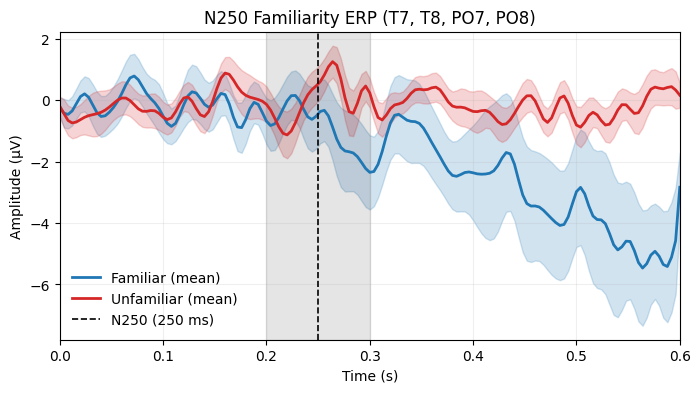

{'component': 'N250', 'avg_method': 'mean', 'smooth_ms': 10.0, 'window_s': [0.2, 0.3], 'channels': ['T7', 'T8', 'PO7', 'PO8'], 'Familiar': {'n': 29, 'mean_uV': -0.8962588025300293, 'sd_uV': 5.071371188190733}, 'Unfamiliar': {'n': 24, 'mean_uV': 0.024338682523977084, 'sd_uV': 1.7114936096927011}}


In [183]:
## Plot N250 familiar vs unfamiliar (averaged across parieto-occipital channels, all valid trials)
try:
    _base_epochs = epochs_ica
except NameError:
    _base_epochs = epochs

fig, stats = plot_familiar_vs_unfamiliar(
    _base_epochs,
    component="N250",
    picks=["T7", "T8", "PO7", "PO8"],
    time_window=(0, 0.6),
    average=True,
    avg_method="mean",
    smooth_ms=10,
    title="N250 Familiarity ERP (T7, T8, PO7, PO8)",
)
print(stats)

N250 analysis:
  Window: 0.200-0.300s
  Channels: ['PO8', 'PO7', 'T8', 'T7']
  Method: mean, Smoothing: 20.0ms
  Familiar: n=10, mean=-0.13 µV, sd=2.81 µV
  Unfamiliar: n=10, mean=0.21 µV, sd=1.73 µV


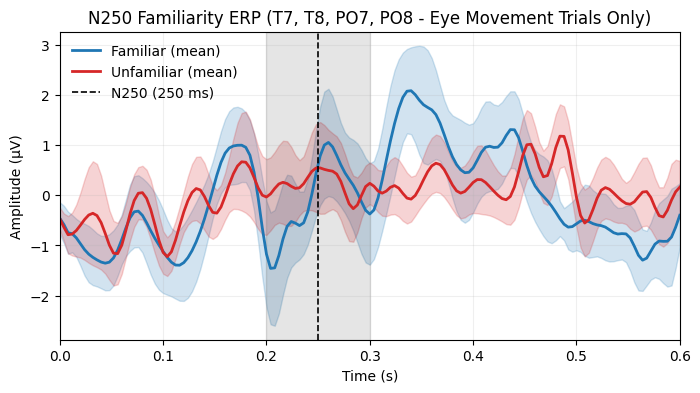

In [56]:
## Try only eye move trials
fig, stats = plot_familiar_vs_unfamiliar(
    _base_epochs['eyes'],
    component="N250",
    picks=["PO8", "PO7", "T8", "T7"],
    time_window=(0, 0.6),
    average=True,
    smooth_ms=20,
    avg_method="mean",
    title="N250 Familiarity ERP (T7, T8, PO7, PO8 - Eye Movement Trials Only)",
)

N250 analysis:
  Window: 0.200-0.300s
  Channels: ['PO8', 'PO7', 'T8', 'T7']
  Method: mean, Smoothing: 20.0ms
  Familiar: n=10, mean=-0.16 µV, sd=2.84 µV
  Unfamiliar: n=10, mean=0.22 µV, sd=1.72 µV


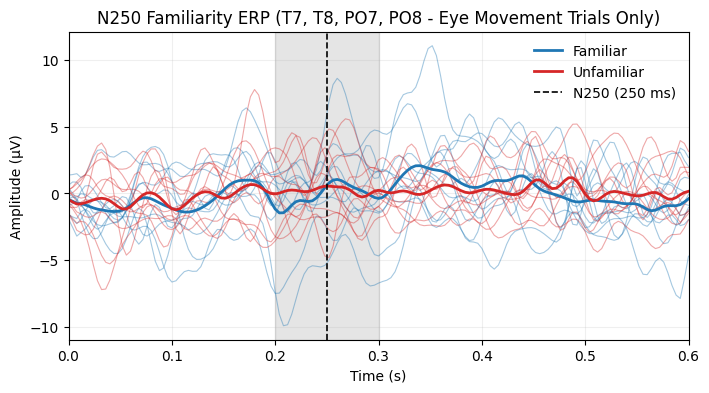

In [187]:
## Plot N250 Familiar vs Unfamiliar (single trials overlaid)
fig, stats = plot_familiar_vs_unfamiliar(
    _base_epochs['eyes'],
    component="N250",
    picks=["PO8", "PO7", "T8", "T7"],
    time_window=(0, 0.6),
    average=False,
    smooth_ms=20,
    avg_method="mean",
    title="N250 Familiarity ERP (T7, T8, PO7, PO8 - Eye Movement Trials Only)",
)

#### T8 (aka T6) only

N250 analysis:
  Window: 0.200-0.300s
  Channels: ['T8']
  Method: mean, Smoothing: 10.0ms
  Familiar: n=29, mean=-3.72 µV, sd=13.39 µV
  Unfamiliar: n=24, mean=-1.19 µV, sd=5.76 µV


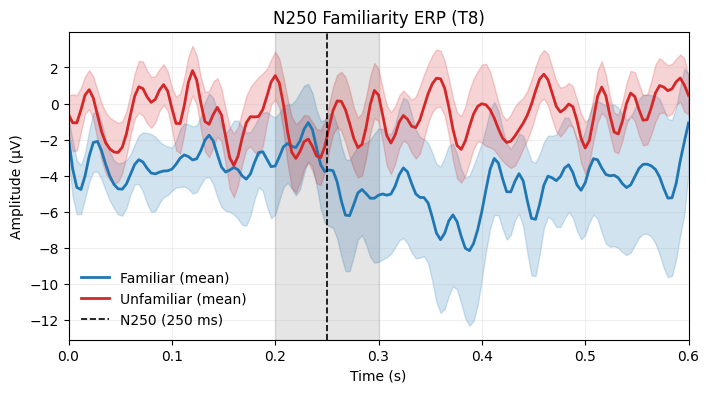

{'component': 'N250', 'avg_method': 'mean', 'smooth_ms': 10.0, 'window_s': [0.2, 0.3], 'channels': ['T8'], 'Familiar': {'n': 29, 'mean_uV': -3.722102314339425, 'sd_uV': 13.386517889748536}, 'Unfamiliar': {'n': 24, 'mean_uV': -1.1935141573823844, 'sd_uV': 5.756397840344765}}


In [63]:
## Plot N250 familiar vs unfamiliar (averaged T8, all valid trials)
try:
    _base_epochs = epochs_ica
except NameError:
    _base_epochs = epochs

fig, stats = plot_familiar_vs_unfamiliar(
    _base_epochs,
    component="N250",
    picks=["T8"],
    time_window=(0, 0.6),
    average=True,
    smooth_ms=10,
    title="N250 Familiarity ERP (T8)",
)
print(stats)

N250 analysis:
  Window: 0.200-0.300s
  Channels: ['T8']
  Method: mean, Smoothing: 20.0ms
  Familiar: n=10, mean=2.00 µV, sd=8.26 µV
  Unfamiliar: n=10, mean=0.49 µV, sd=4.22 µV


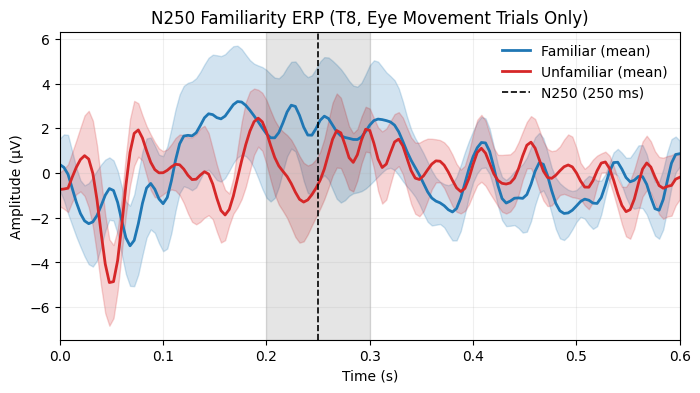

{'component': 'N250', 'avg_method': 'mean', 'smooth_ms': 20.0, 'window_s': [0.2, 0.3], 'channels': ['T8'], 'Familiar': {'n': 10, 'mean_uV': 1.9984067877774585, 'sd_uV': 8.25720625877148}, 'Unfamiliar': {'n': 10, 'mean_uV': 0.48712237329640884, 'sd_uV': 4.215671510506916}}


In [65]:
## Eye movements only
fig, stats = plot_familiar_vs_unfamiliar(
    _base_epochs['eyes'],
    component="N250",
    picks=["T8"],
    time_window=(0, 0.6),
    average=True,
    smooth_ms=20,
    avg_method="mean",
    title="N250 Familiarity ERP (T8, Eye Movement Trials Only)",
)
print(stats)

N250 analysis:
  Window: 0.200-0.300s
  Channels: ['T8']
  Method: mean, Smoothing: 20.0ms
  Familiar: n=10, mean=2.00 µV, sd=8.26 µV
  Unfamiliar: n=10, mean=0.49 µV, sd=4.22 µV


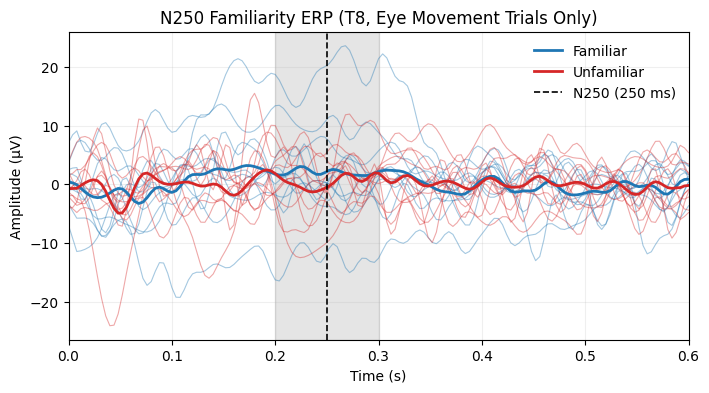

{'component': 'N250', 'avg_method': 'mean', 'smooth_ms': 20.0, 'window_s': [0.2, 0.3], 'channels': ['T8'], 'Familiar': {'n': 10, 'mean_uV': 1.9984067877774585, 'sd_uV': 8.25720625877148}, 'Unfamiliar': {'n': 10, 'mean_uV': 0.48712237329640884, 'sd_uV': 4.215671510506916}}


In [70]:
## Eye movements only (all trials)
fig, stats = plot_familiar_vs_unfamiliar(
    _base_epochs['eyes'],
    component="N250",
    picks=["T8"],
    time_window=(0, 0.6),
    average=False,
    smooth_ms=20,
    avg_method="median",
    title="N250 Familiarity ERP (T8, Eye Movement Trials Only)",
)
print(stats)

N250 analysis:
  Window: 0.200-0.300s
  Channels: ['T8']
  Method: mean, Smoothing: 20.0ms
  Familiar: n=9, mean=-13.94 µV, sd=19.15 µV
  Unfamiliar: n=5, mean=-4.42 µV, sd=8.31 µV


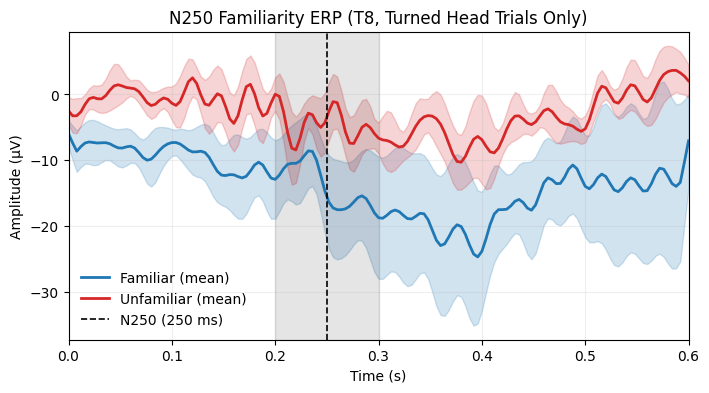

{'component': 'N250', 'avg_method': 'mean', 'smooth_ms': 20.0, 'window_s': [0.2, 0.3], 'channels': ['T8'], 'Familiar': {'n': 9, 'mean_uV': -13.936373842147887, 'sd_uV': 19.152289055297906}, 'Unfamiliar': {'n': 5, 'mean_uV': -4.42240257466044, 'sd_uV': 8.309451460047388}}


In [73]:
## Turned head only
fig, stats = plot_familiar_vs_unfamiliar(
    _base_epochs['turn'],
    component="N250",
    picks=["T8"],
    time_window=(0, 0.6),
    average=True,
    smooth_ms=20,
    title="N250 Familiarity ERP (T8, Turned Head Trials Only)",
)
print(stats)

N250 analysis:
  Window: 0.200-0.300s
  Channels: ['T8']
  Method: mean, Smoothing: 20.0ms
  Familiar: n=9, mean=-13.94 µV, sd=19.15 µV
  Unfamiliar: n=5, mean=-4.42 µV, sd=8.31 µV


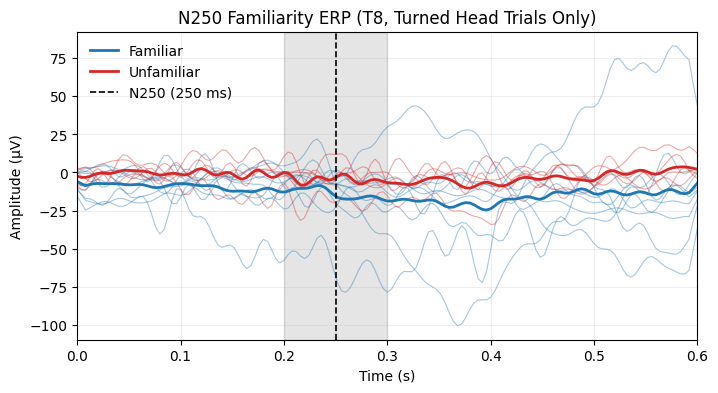

{'component': 'N250', 'avg_method': 'mean', 'smooth_ms': 20.0, 'window_s': [0.2, 0.3], 'channels': ['T8'], 'Familiar': {'n': 9, 'mean_uV': -13.936373842147887, 'sd_uV': 19.152289055297906}, 'Unfamiliar': {'n': 5, 'mean_uV': -4.42240257466044, 'sd_uV': 8.309451460047388}}


In [71]:
## Head turn only (all trials)
try:
    _base_epochs = epochs_ica
except NameError:
    _base_epochs = epochs

fig, stats = plot_familiar_vs_unfamiliar(
    _base_epochs['turn'],
    component="N250",
    picks=["T8"],
    time_window=(0, 0.6),
    average=False,
    smooth_ms=20,
    title="N250 Familiarity ERP (T8, Turned Head Trials Only)",
)
print(stats)

#### F2 only

N250 analysis:
  Window: 0.200-0.300s
  Channels: ['F2']
  Method: mean, Smoothing: 10.0ms
  Familiar: n=29, mean=1.36 µV, sd=7.62 µV
  Unfamiliar: n=24, mean=-0.19 µV, sd=3.95 µV


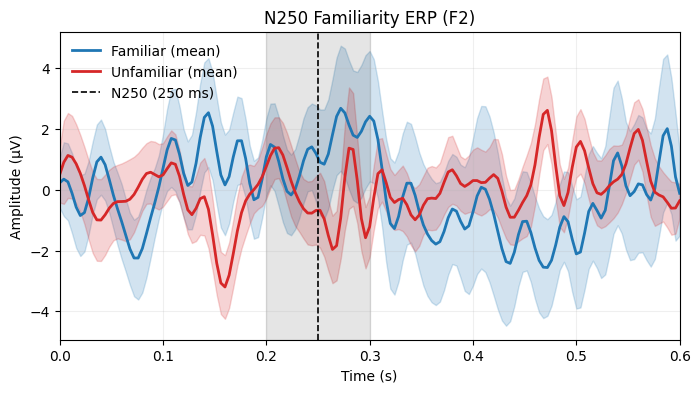

{'component': 'N250', 'avg_method': 'mean', 'smooth_ms': 10.0, 'window_s': [0.2, 0.3], 'channels': ['F2'], 'Familiar': {'n': 29, 'mean_uV': 1.358603559325499, 'sd_uV': 7.622298948680898}, 'Unfamiliar': {'n': 24, 'mean_uV': -0.1944842128582129, 'sd_uV': 3.952815821927091}}


In [76]:
## Plot N250 familiar vs unfamiliar (averaged F2, all valid trials)
try:
    _base_epochs = epochs_ica
except NameError:
    _base_epochs = epochs

fig, stats = plot_familiar_vs_unfamiliar(
    _base_epochs,
    component="N250",
    picks=["F2"],
    time_window=(0, 0.6),
    average=True,
    smooth_ms=10,
    title="N250 Familiarity ERP (F2)",
)
print(stats)

N250 analysis:
  Window: 0.200-0.300s
  Channels: ['F2']
  Method: mean, Smoothing: 20.0ms
  Familiar: n=10, mean=2.48 µV, sd=8.65 µV
  Unfamiliar: n=10, mean=-0.16 µV, sd=4.03 µV


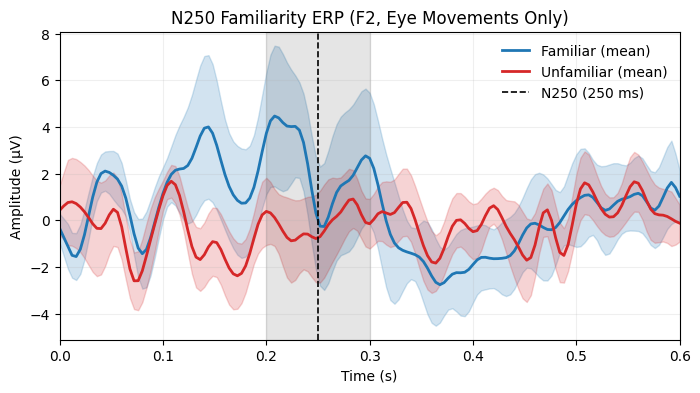

{'component': 'N250', 'avg_method': 'mean', 'smooth_ms': 20.0, 'window_s': [0.2, 0.3], 'channels': ['F2'], 'Familiar': {'n': 10, 'mean_uV': 2.475389747518948, 'sd_uV': 8.654416427494947}, 'Unfamiliar': {'n': 10, 'mean_uV': -0.16221534715477057, 'sd_uV': 4.029819339738324}}


In [77]:
## Eye movements only
fig, stats = plot_familiar_vs_unfamiliar(
    _base_epochs['eyes'],
    component="N250",
    picks=["F2"],
    time_window=(0, 0.6),
    average=True,
    smooth_ms=20,
    avg_method="mean",
    title="N250 Familiarity ERP (F2, Eye Movements Only)",
)
print(stats)

N250 analysis:
  Window: 0.200-0.300s
  Channels: ['F2']
  Method: mean, Smoothing: 20.0ms
  Familiar: n=10, mean=2.48 µV, sd=8.65 µV
  Unfamiliar: n=10, mean=-0.16 µV, sd=4.03 µV


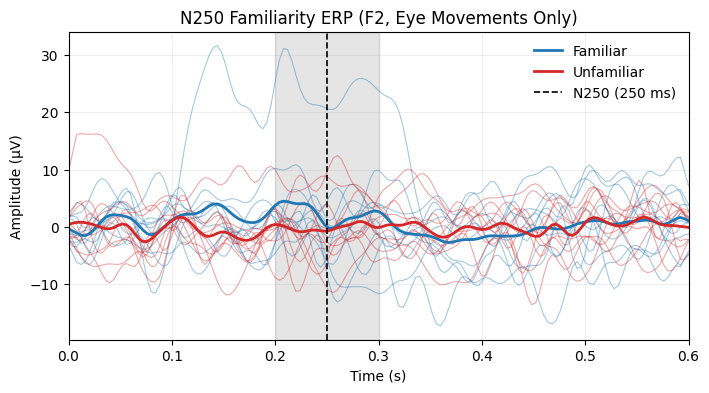

{'component': 'N250', 'avg_method': 'mean', 'smooth_ms': 20.0, 'window_s': [0.2, 0.3], 'channels': ['F2'], 'Familiar': {'n': 10, 'mean_uV': 2.475389747518948, 'sd_uV': 8.654416427494947}, 'Unfamiliar': {'n': 10, 'mean_uV': -0.16221534715477057, 'sd_uV': 4.029819339738324}}


In [78]:
## Eye movements only (all trials)
fig, stats = plot_familiar_vs_unfamiliar(
    _base_epochs['eyes'],
    component="N250",
    picks=["F2"],
    time_window=(0, 0.6),
    average=False,
    smooth_ms=20,
    title="N250 Familiarity ERP (F2, Eye Movements Only)",
)
print(stats)

N250 analysis:
  Window: 0.200-0.300s
  Channels: ['F2']
  Method: mean, Smoothing: 20.0ms
  Familiar: n=9, mean=-1.25 µV, sd=9.05 µV
  Unfamiliar: n=5, mean=-0.24 µV, sd=4.13 µV


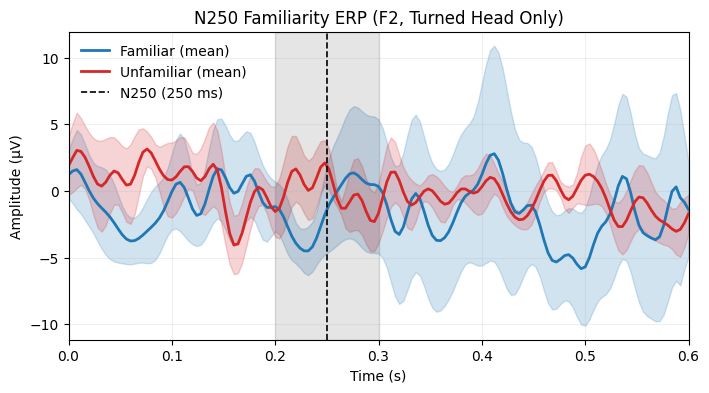

{'component': 'N250', 'avg_method': 'mean', 'smooth_ms': 20.0, 'window_s': [0.2, 0.3], 'channels': ['F2'], 'Familiar': {'n': 9, 'mean_uV': -1.2538730168949732, 'sd_uV': 9.053606650595185}, 'Unfamiliar': {'n': 5, 'mean_uV': -0.23579979439111076, 'sd_uV': 4.133961437100856}}


In [79]:
## Turned head only
fig, stats = plot_familiar_vs_unfamiliar(
    _base_epochs['turn'],
    component="N250",
    picks=["F2"],
    time_window=(0, 0.6),
    average=True,
    smooth_ms=20,
    title="N250 Familiarity ERP (F2, Turned Head Only)",
)
print(stats)

N250 analysis:
  Window: 0.200-0.300s
  Channels: ['F2']
  Method: mean, Smoothing: 20.0ms
  Familiar: n=9, mean=-1.25 µV, sd=9.05 µV
  Unfamiliar: n=5, mean=-0.24 µV, sd=4.13 µV


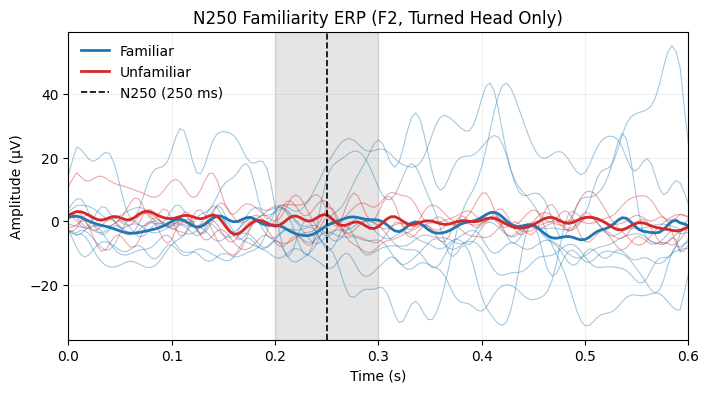

{'component': 'N250', 'avg_method': 'mean', 'smooth_ms': 20.0, 'window_s': [0.2, 0.3], 'channels': ['F2'], 'Familiar': {'n': 9, 'mean_uV': -1.2538730168949732, 'sd_uV': 9.053606650595185}, 'Unfamiliar': {'n': 5, 'mean_uV': -0.23579979439111076, 'sd_uV': 4.133961437100856}}


In [ ]:
## Turned head only (all trials)
fig, stats = plot_familiar_vs_unfamiliar(
    _base_epochs['turn'],
    component="N250",
    picks=["F2"],
    time_window=(0, 0.6),
    average=False,
    smooth_ms=20,
    title="N250 Familiarity ERP (F2, Turned Head Only)",
)
print(stats)

### Plot P300

#### Midline channels averaged (PZ, CZ)

P300 analysis:
  Window: 0.250-0.350s
  Channels: ['Pz', 'Cz']
  Method: mean, Smoothing: 10.0ms
  Familiar: n=29, mean=1.94 µV, sd=8.33 µV
  Unfamiliar: n=24, mean=-0.12 µV, sd=2.23 µV


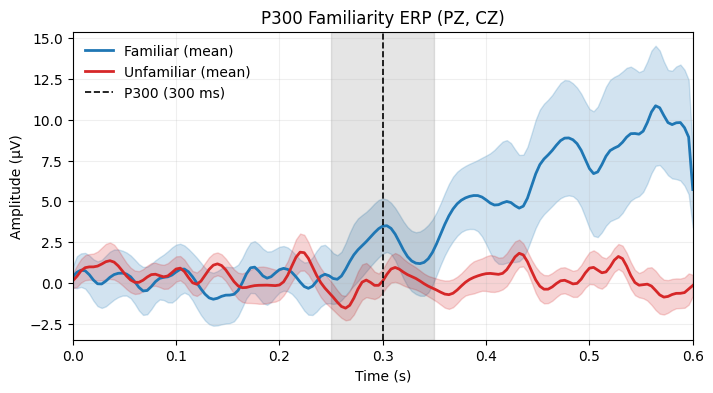

{'component': 'P300', 'avg_method': 'mean', 'smooth_ms': 10.0, 'window_s': [0.25, 0.35], 'channels': ['Pz', 'Cz'], 'Familiar': {'n': 29, 'mean_uV': 1.9417028335999182, 'sd_uV': 8.326010152146651}, 'Unfamiliar': {'n': 24, 'mean_uV': -0.11549617978626192, 'sd_uV': 2.233193071177911}}


In [81]:
## Plot P300 familiar vs unfamiliar (averaged PZ and CZ, all valid trials)
try:
    _base_epochs = epochs_ica
except NameError:
    _base_epochs = epochs

fig, stats = plot_familiar_vs_unfamiliar(
    _base_epochs,
    component="P300",
    picks=["PZ", "CZ"],
    time_window=(0, 0.6),
    average=True,
    smooth_ms=10,
    avg_method="mean",
    title="P300 Familiarity ERP (PZ, CZ)",
)
print(stats)

P300 analysis:
  Window: 0.250-0.350s
  Channels: ['Pz', 'Cz']
  Method: mean, Smoothing: 20.0ms
  Familiar: n=10, mean=-1.92 µV, sd=2.68 µV
  Unfamiliar: n=10, mean=-0.39 µV, sd=1.88 µV


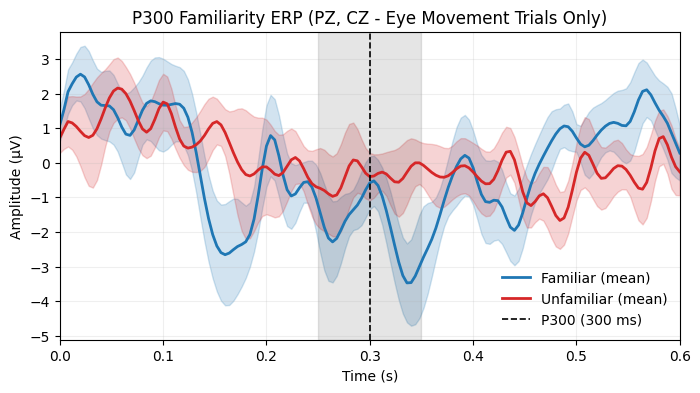

{'component': 'P300', 'avg_method': 'mean', 'smooth_ms': 20.0, 'window_s': [0.25, 0.35], 'channels': ['Pz', 'Cz'], 'Familiar': {'n': 10, 'mean_uV': -1.9164555129975724, 'sd_uV': 2.6758284079706627}, 'Unfamiliar': {'n': 10, 'mean_uV': -0.38673613830553233, 'sd_uV': 1.8775419018991542}}


In [83]:
## Eye movements only
fig, stats = plot_familiar_vs_unfamiliar(
    _base_epochs['eyes'],
    component="P300",
    picks=["PZ", "CZ"],
    time_window=(0, 0.6),
    average=True,
    smooth_ms=20,
    avg_method="mean",
    title="P300 Familiarity ERP (PZ, CZ - Eye Movement Trials Only)",
)
print(stats)

P300 analysis:
  Window: 0.250-0.350s
  Channels: ['Pz', 'Cz']
  Method: mean, Smoothing: 20.0ms
  Familiar: n=10, mean=-1.92 µV, sd=2.68 µV
  Unfamiliar: n=10, mean=-0.39 µV, sd=1.88 µV


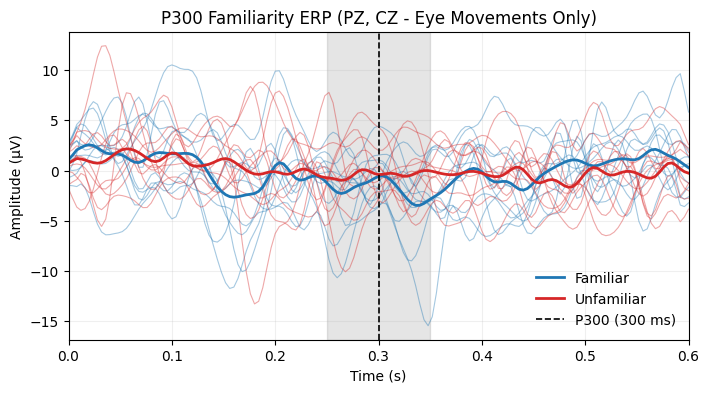

{'component': 'P300', 'avg_method': 'mean', 'smooth_ms': 20.0, 'window_s': [0.25, 0.35], 'channels': ['Pz', 'Cz'], 'Familiar': {'n': 10, 'mean_uV': -1.9164555129975724, 'sd_uV': 2.6758284079706627}, 'Unfamiliar': {'n': 10, 'mean_uV': -0.38673613830553233, 'sd_uV': 1.8775419018991542}}


In [84]:
## Eye movements only (all trials)
fig, stats = plot_familiar_vs_unfamiliar(
    _base_epochs['eyes'],
    component="P300",
    picks=["PZ", "CZ"],
    time_window=(0, 0.6),
    average=False,
    smooth_ms=20,
    title="P300 Familiarity ERP (PZ, CZ - Eye Movements Only)",
)
print(stats)

P300 analysis:
  Window: 0.250-0.350s
  Channels: ['Pz', 'Cz']
  Method: mean, Smoothing: 20.0ms
  Familiar: n=9, mean=5.38 µV, sd=13.48 µV
  Unfamiliar: n=5, mean=1.36 µV, sd=1.21 µV


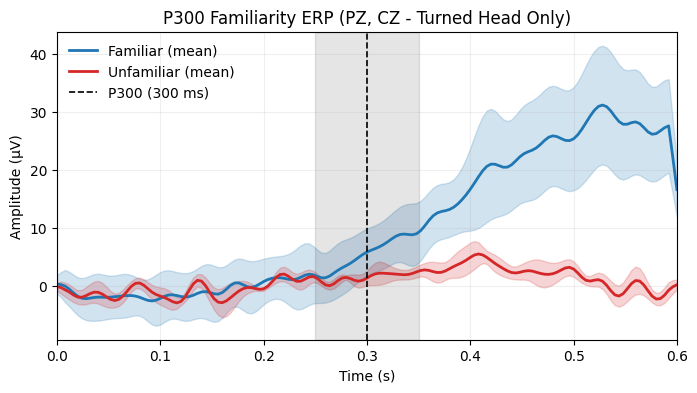

{'component': 'P300', 'avg_method': 'mean', 'smooth_ms': 20.0, 'window_s': [0.25, 0.35], 'channels': ['Pz', 'Cz'], 'Familiar': {'n': 9, 'mean_uV': 5.381759345198923, 'sd_uV': 13.479328977467087}, 'Unfamiliar': {'n': 5, 'mean_uV': 1.3602954785767452, 'sd_uV': 1.2091297892754909}}


In [86]:
## Turned head only
fig, stats = plot_familiar_vs_unfamiliar(
    _base_epochs['turn'],
    component="P300",
    picks=["PZ", "CZ"],
    time_window=(0, 0.6),
    average=True,
    smooth_ms=20,
    title="P300 Familiarity ERP (PZ, CZ - Turned Head Only)",
)
print(stats)

P300 analysis:
  Window: 0.250-0.350s
  Channels: ['Pz', 'Cz']
  Method: mean, Smoothing: 20.0ms
  Familiar: n=9, mean=5.38 µV, sd=13.48 µV
  Unfamiliar: n=5, mean=1.36 µV, sd=1.21 µV


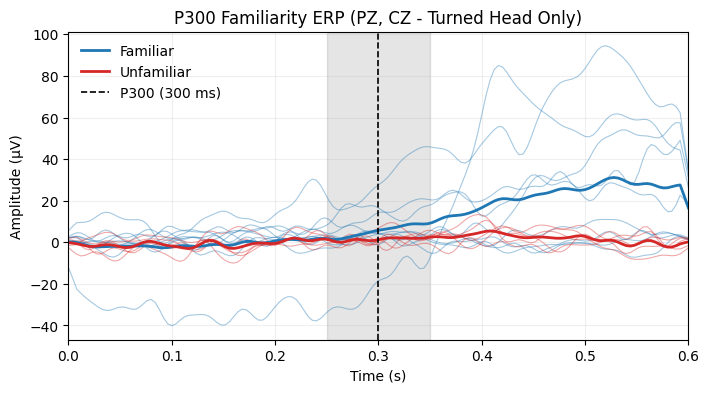

{'component': 'P300', 'avg_method': 'mean', 'smooth_ms': 20.0, 'window_s': [0.25, 0.35], 'channels': ['Pz', 'Cz'], 'Familiar': {'n': 9, 'mean_uV': 5.381759345198923, 'sd_uV': 13.479328977467087}, 'Unfamiliar': {'n': 5, 'mean_uV': 1.3602954785767452, 'sd_uV': 1.2091297892754909}}


In [87]:
## Turned head only (all trials)
fig, stats = plot_familiar_vs_unfamiliar(
    _base_epochs['turn'],
    component="P300",
    picks=["PZ", "CZ"],
    time_window=(0, 0.6),
    average=False,
    smooth_ms=20,
    title="P300 Familiarity ERP (PZ, CZ - Turned Head Only)",
)
print(stats)

#### Pz Only

P300 analysis:
  Window: 0.250-0.350s
  Channels: ['Pz']
  Method: mean, Smoothing: 10.0ms
  Familiar: n=29, mean=-2.33 µV, sd=7.66 µV
  Unfamiliar: n=24, mean=0.06 µV, sd=2.70 µV


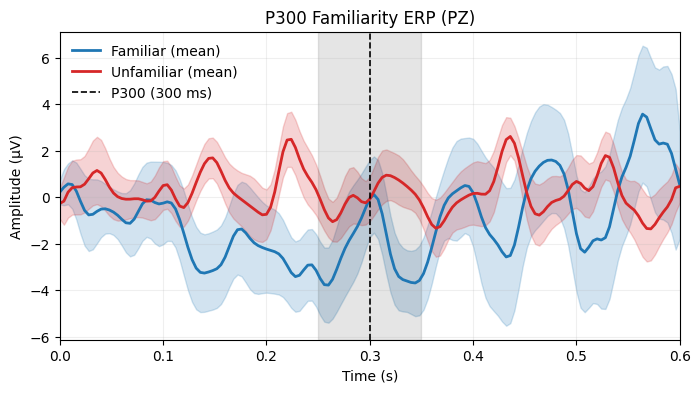

{'component': 'P300', 'avg_method': 'mean', 'smooth_ms': 10.0, 'window_s': [0.25, 0.35], 'channels': ['Pz'], 'Familiar': {'n': 29, 'mean_uV': -2.327840300406704, 'sd_uV': 7.655758996371591}, 'Unfamiliar': {'n': 24, 'mean_uV': 0.06053345313006275, 'sd_uV': 2.703496505847923}}


In [97]:
## Plot P300 familiar vs unfamiliar (averaged PZ, all valid trials)
try:
    _base_epochs = epochs_ica
except NameError:
    _base_epochs = epochs

fig, stats = plot_familiar_vs_unfamiliar(
    _base_epochs,
    component="P300",
    picks=["PZ"],
    time_window=(0, 0.6),
    average=True,
    smooth_ms=10,
    avg_method="mean",
    title="P300 Familiarity ERP (PZ)",
)
print(stats)

P300 analysis:
  Window: 0.250-0.350s
  Channels: ['Pz']
  Method: mean, Smoothing: 20.0ms
  Familiar: n=10, mean=-2.34 µV, sd=2.25 µV
  Unfamiliar: n=10, mean=-0.62 µV, sd=2.63 µV


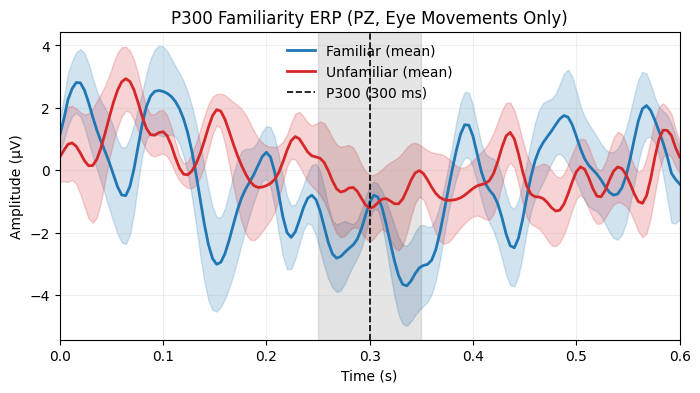

{'component': 'P300', 'avg_method': 'mean', 'smooth_ms': 20.0, 'window_s': [0.25, 0.35], 'channels': ['Pz'], 'Familiar': {'n': 10, 'mean_uV': -2.3382456585530065, 'sd_uV': 2.2512065719795324}, 'Unfamiliar': {'n': 10, 'mean_uV': -0.6158047358724161, 'sd_uV': 2.6340805833345726}}


In [90]:
## Eye movements only
fig, stats = plot_familiar_vs_unfamiliar(
    _base_epochs['eyes'],
    component="P300",
    picks=["PZ"],
    time_window=(0, 0.6),
    average=True,
    smooth_ms=20,
    avg_method="mean",
    title="P300 Familiarity ERP (PZ, Eye Movements Only)",
)
print(stats)

P300 analysis:
  Window: 0.250-0.350s
  Channels: ['Pz']
  Method: mean, Smoothing: 20.0ms
  Familiar: n=10, mean=-2.34 µV, sd=2.25 µV
  Unfamiliar: n=10, mean=-0.62 µV, sd=2.63 µV


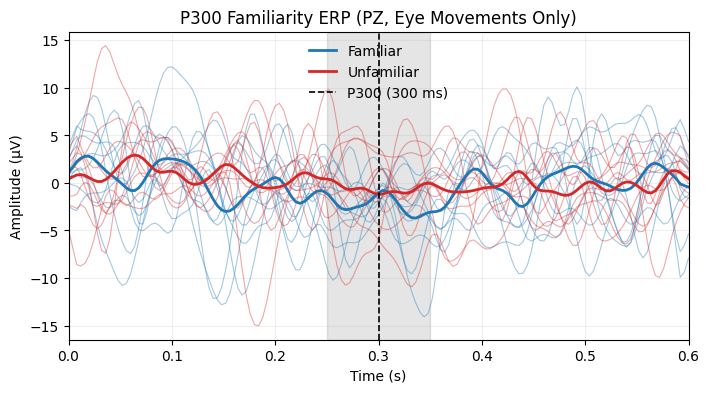

{'component': 'P300', 'avg_method': 'mean', 'smooth_ms': 20.0, 'window_s': [0.25, 0.35], 'channels': ['Pz'], 'Familiar': {'n': 10, 'mean_uV': -2.3382456585530065, 'sd_uV': 2.2512065719795324}, 'Unfamiliar': {'n': 10, 'mean_uV': -0.6158047358724161, 'sd_uV': 2.6340805833345726}}


In [91]:
## Eye movements only (all trials)
fig, stats = plot_familiar_vs_unfamiliar(
    _base_epochs['eyes'],
    component="P300",
    picks=["PZ"],
    time_window=(0, 0.6),
    average=False,
    smooth_ms=20,
    title="P300 Familiarity ERP (PZ, Eye Movements Only)",
)
print(stats)

P300 analysis:
  Window: 0.250-0.350s
  Channels: ['Pz']
  Method: mean, Smoothing: 20.0ms
  Familiar: n=9, mean=-7.83 µV, sd=10.79 µV
  Unfamiliar: n=5, mean=2.08 µV, sd=2.88 µV


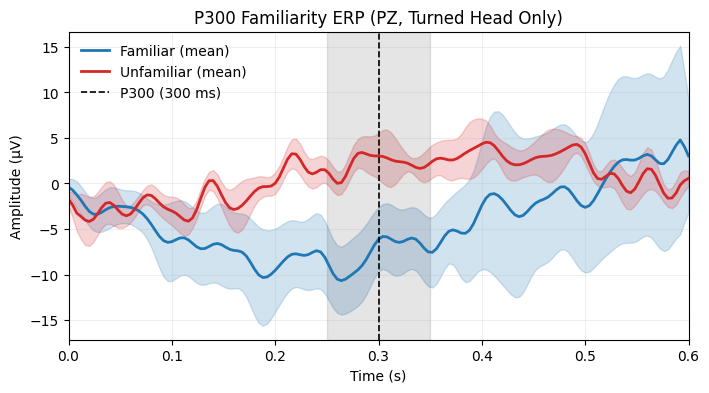

{'component': 'P300', 'avg_method': 'mean', 'smooth_ms': 20.0, 'window_s': [0.25, 0.35], 'channels': ['Pz'], 'Familiar': {'n': 9, 'mean_uV': -7.826135227565108, 'sd_uV': 10.791788384814243}, 'Unfamiliar': {'n': 5, 'mean_uV': 2.0788236324165155, 'sd_uV': 2.878456645591982}}


In [ ]:
## Turned head only
fig, stats = plot_familiar_vs_unfamiliar(
    _base_epochs['turn'],
    component="P300",
    picks=["PZ"],
    time_window=(0, 0.6),
    average=True,
    smooth_ms=20,
    title="P300 Familiarity ERP (PZ, Turned Head Only)",
)
print(stats)

P300 analysis:
  Window: 0.250-0.350s
  Channels: ['Pz']
  Method: mean, Smoothing: 20.0ms
  Familiar: n=9, mean=-7.83 µV, sd=10.79 µV
  Unfamiliar: n=5, mean=2.08 µV, sd=2.88 µV


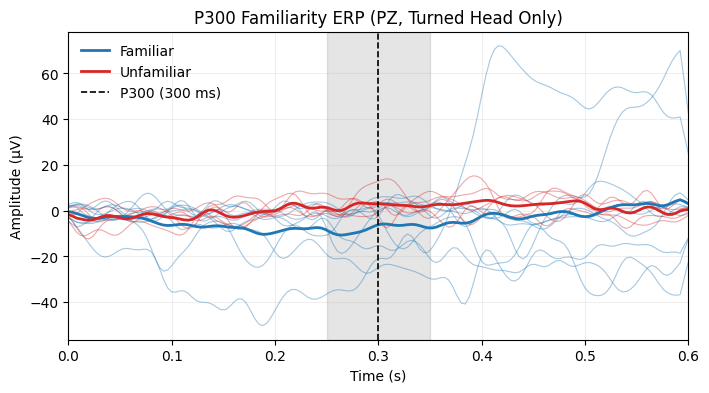

{'component': 'P300', 'avg_method': 'mean', 'smooth_ms': 20.0, 'window_s': [0.25, 0.35], 'channels': ['Pz'], 'Familiar': {'n': 9, 'mean_uV': -7.826135227565108, 'sd_uV': 10.791788384814243}, 'Unfamiliar': {'n': 5, 'mean_uV': 2.0788236324165155, 'sd_uV': 2.878456645591982}}


In [95]:
## Turned head only (all trials)
fig, stats = plot_familiar_vs_unfamiliar(
    _base_epochs['turn'],
    component="P300",
    picks=["PZ"],
    time_window=(0, 0.6),
    average=False,
    smooth_ms=20,
    title="P300 Familiarity ERP (PZ, Turned Head Only)",
)
print(stats)

#### Cz Only

P300 analysis:
  Window: 0.250-0.350s
  Channels: ['Cz']
  Method: mean, Smoothing: 10.0ms
  Familiar: n=29, mean=6.21 µV, sd=16.77 µV
  Unfamiliar: n=24, mean=-0.29 µV, sd=3.07 µV


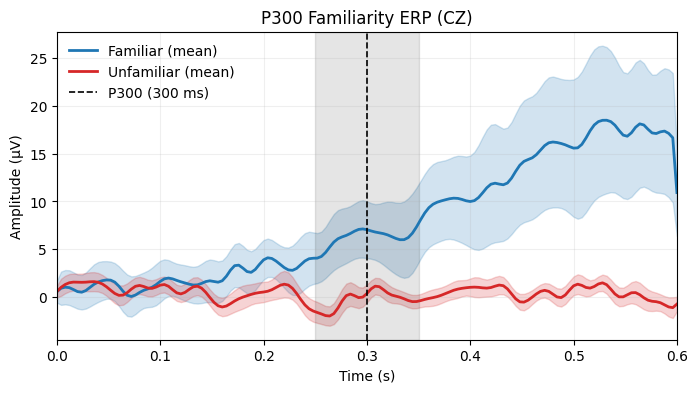

{'component': 'P300', 'avg_method': 'mean', 'smooth_ms': 10.0, 'window_s': [0.25, 0.35], 'channels': ['Cz'], 'Familiar': {'n': 29, 'mean_uV': 6.211245967606541, 'sd_uV': 16.76962574943776}, 'Unfamiliar': {'n': 24, 'mean_uV': -0.2915258127025866, 'sd_uV': 3.066339591838399}}


In [99]:
## Plot P300 familiar vs unfamiliar (averaged CZ, all valid trials)
try:
    _base_epochs = epochs_ica
except NameError:
    _base_epochs = epochs

fig, stats = plot_familiar_vs_unfamiliar(
    _base_epochs,
    component="P300",
    picks=["CZ"],
    time_window=(0, 0.6),
    average=True,
    smooth_ms=10,
    avg_method="mean",
    title="P300 Familiarity ERP (CZ)",
)
print(stats)

P300 analysis:
  Window: 0.250-0.350s
  Channels: ['Cz']
  Method: mean, Smoothing: 20.0ms
  Familiar: n=10, mean=-1.49 µV, sd=3.51 µV
  Unfamiliar: n=10, mean=-0.16 µV, sd=2.35 µV


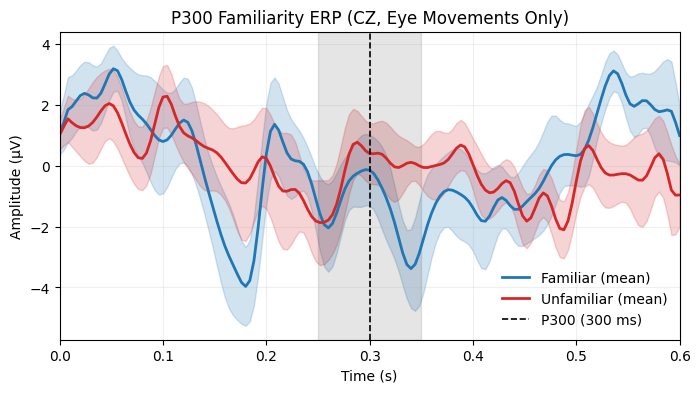

{'component': 'P300', 'avg_method': 'mean', 'smooth_ms': 20.0, 'window_s': [0.25, 0.35], 'channels': ['Cz'], 'Familiar': {'n': 10, 'mean_uV': -1.4946653674421384, 'sd_uV': 3.5098475003062615}, 'Unfamiliar': {'n': 10, 'mean_uV': -0.15766754073864853, 'sd_uV': 2.3480121411445047}}


In [104]:
## Eye movements only
fig, stats = plot_familiar_vs_unfamiliar(
    _base_epochs['eyes'],
    component="P300",
    picks=["CZ"],
    time_window=(0, 0.6),
    average=True,
    smooth_ms=20,
    avg_method="mean",
    title="P300 Familiarity ERP (CZ, Eye Movements Only)",
)
print(stats)

P300 analysis:
  Window: 0.250-0.350s
  Channels: ['Cz']
  Method: mean, Smoothing: 20.0ms
  Familiar: n=10, mean=-1.49 µV, sd=3.51 µV
  Unfamiliar: n=10, mean=-0.16 µV, sd=2.35 µV


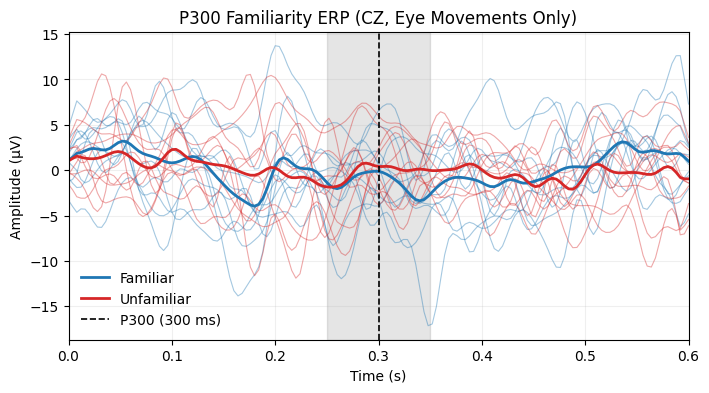

{'component': 'P300', 'avg_method': 'mean', 'smooth_ms': 20.0, 'window_s': [0.25, 0.35], 'channels': ['Cz'], 'Familiar': {'n': 10, 'mean_uV': -1.4946653674421384, 'sd_uV': 3.5098475003062615}, 'Unfamiliar': {'n': 10, 'mean_uV': -0.15766754073864853, 'sd_uV': 2.3480121411445047}}


In [105]:
## Eye movements only (all trials)
fig, stats = plot_familiar_vs_unfamiliar(
    _base_epochs['eyes'],
    component="P300",
    picks=["CZ"],
    time_window=(0, 0.6),
    average=False,
    smooth_ms=20,
    title="P300 Familiarity ERP (CZ, Eye Movements Only)",
)
print(stats)

P300 analysis:
  Window: 0.250-0.350s
  Channels: ['Cz']
  Method: mean, Smoothing: 20.0ms
  Familiar: n=9, mean=18.59 µV, sd=26.16 µV
  Unfamiliar: n=5, mean=0.64 µV, sd=1.28 µV


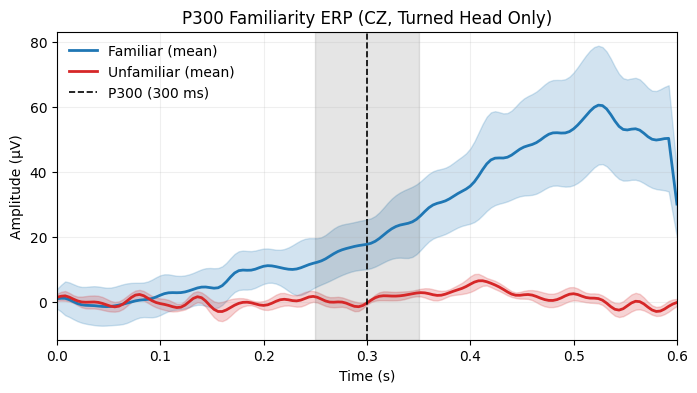

{'component': 'P300', 'avg_method': 'mean', 'smooth_ms': 20.0, 'window_s': [0.25, 0.35], 'channels': ['Cz'], 'Familiar': {'n': 9, 'mean_uV': 18.589653917962956, 'sd_uV': 26.160572823552915}, 'Unfamiliar': {'n': 5, 'mean_uV': 0.6417673247369748, 'sd_uV': 1.2753575098046925}}


In [103]:
## Turned head only
fig, stats = plot_familiar_vs_unfamiliar(
    _base_epochs['turn'],
    component="P300",
    picks=["CZ"],
    time_window=(0, 0.6),
    average=True,
    smooth_ms=20,
    title="P300 Familiarity ERP (CZ, Turned Head Only)",
)
print(stats)

P300 analysis:
  Window: 0.250-0.350s
  Channels: ['Cz']
  Method: mean, Smoothing: 20.0ms
  Familiar: n=9, mean=18.59 µV, sd=26.16 µV
  Unfamiliar: n=5, mean=0.64 µV, sd=1.28 µV


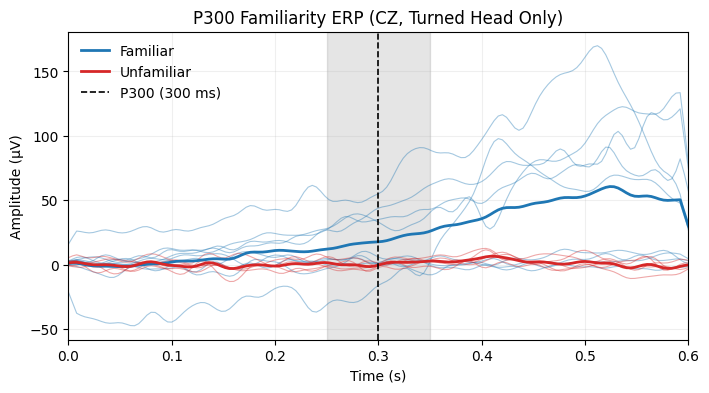

{'component': 'P300', 'avg_method': 'mean', 'smooth_ms': 20.0, 'window_s': [0.25, 0.35], 'channels': ['Cz'], 'Familiar': {'n': 9, 'mean_uV': 18.589653917962956, 'sd_uV': 26.160572823552915}, 'Unfamiliar': {'n': 5, 'mean_uV': 0.6417673247369748, 'sd_uV': 1.2753575098046925}}


In [107]:
## Turned head only (all trials)
fig, stats = plot_familiar_vs_unfamiliar(
    _base_epochs['turn'],
    component="P300",
    picks=["CZ"],
    time_window=(0, 0.6),
    average=False,
    smooth_ms=20,
    title="P300 Familiarity ERP (CZ, Turned Head Only)",
)
print(stats)